<a href="https://colab.research.google.com/github/AgenticGovernace/AgenticGovernance-ArtemisCity/blob/main/SIMULATION%20DOC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.neural_network import MLPRegressor
import numpy as np

# Initialize Optimized High-Capacity Agents
n_agents = 5
optimized_agents = [
    MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        learning_rate_init=0.005,
        random_state=i
    ) for i in range(n_agents)
]

# Initialize weights for the optimized agents
optimized_weights = np.ones(n_agents)

print("Initialized 5 Optimized High-Capacity Hebbian Agents.")

Initialized 5 Optimized High-Capacity Hebbian Agents.


Running Traditional Inference (k-NN)...
Running Standard Hebbian (No Decay)...
Running Adaptive Hebbian (With Decay)...


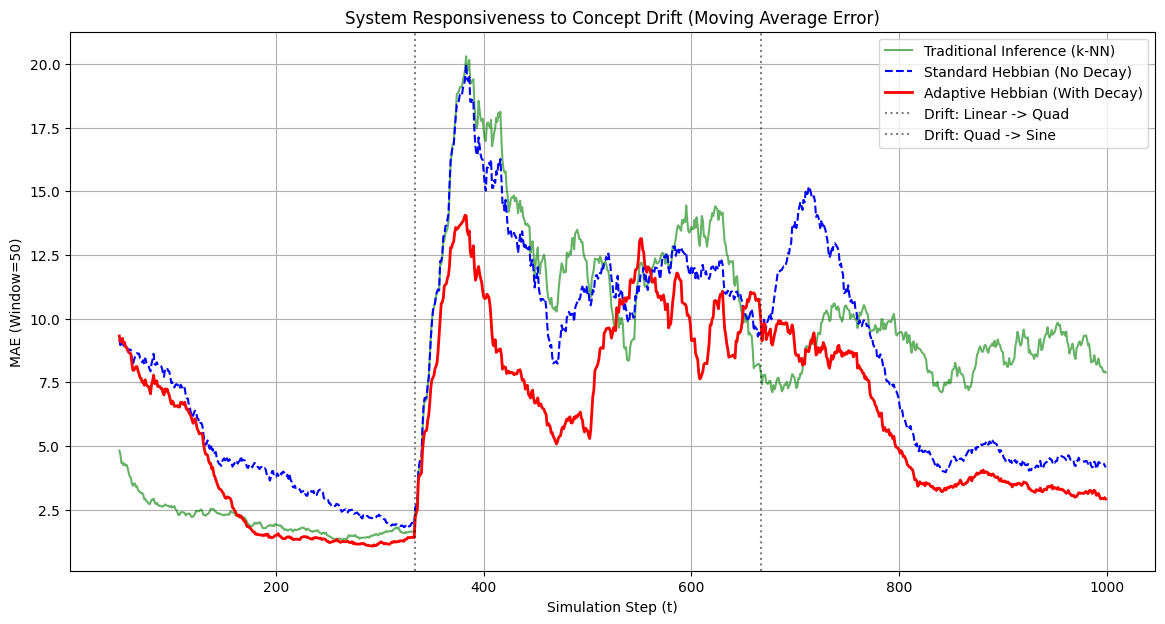

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Simulation Parameters ---
window_size = 50
k_neighbors = 5
n_agents = 5

# --- 1. Traditional Inference (Online k-NN) ---
print("Running Traditional Inference (k-NN)...")
X_mem = []
y_mem = []
knn_errors = []

for t in range(len(X_dynamic)):
    x_t = X_dynamic[t].reshape(1, -1)
    y_t = y_dynamic[t]

    if len(X_mem) < k_neighbors:
        y_pred = np.mean(y_mem) if y_mem else 0.0
    else:
        # Optimization: In a real scenario, use a spatial index. For N=1000, brute force is fine.
        dists = pairwise_distances(x_t, np.array(X_mem))[0]
        idx = np.argsort(dists)[:k_neighbors]
        y_pred = np.mean(np.array(y_mem)[idx])

    knn_errors.append(np.abs(y_t - y_pred))
    X_mem.append(X_dynamic[t])
    y_mem.append(y_t)

# --- 2. Standard Hebbian (No Decay) ---
print("Running Standard Hebbian (No Decay)...")
std_agents = [MLPRegressor(hidden_layer_sizes=(100, 50), learning_rate_init=0.005, random_state=i) for i in range(n_agents)]
std_weights = np.ones(n_agents)
std_errors = []

for t in range(len(X_dynamic)):
    x_t = X_dynamic[t].reshape(1, -1)
    y_t = y_dynamic[t:t+1]

    # Select
    candidates = np.where(std_weights == np.max(std_weights))[0]
    agent = std_agents[np.random.choice(candidates)]

    # Predict
    try:
        y_pred = agent.predict(x_t)[0]
    except:
        y_pred = 0.0

    # Error
    err = np.abs(y_t[0] - y_pred)
    std_errors.append(err)

    # Update Weights (Standard: Infinite Memory of Success)
    if err < 5.0:
        std_weights[candidates] += 1.0
    else:
        std_weights[candidates] = np.maximum(0, std_weights[candidates] - 1.0)

    # Train
    agent.partial_fit(x_t, y_t)

# --- 3. Adaptive Hebbian (With Decay) ---
print("Running Adaptive Hebbian (With Decay)...")
adapt_agents = [MLPRegressor(hidden_layer_sizes=(100, 50), learning_rate_init=0.005, random_state=i) for i in range(n_agents)]
adapt_weights = np.ones(n_agents)
adapt_errors = []
decay_rate = 0.99 # Slightly aggressive decay to handle drift

for t in range(len(X_dynamic)):
    x_t = X_dynamic[t].reshape(1, -1)
    y_t = y_dynamic[t:t+1]

    # Select
    candidates = np.where(adapt_weights == np.max(adapt_weights))[0]
    idx = np.random.choice(candidates)
    agent = adapt_agents[idx]

    # Predict
    try:
        y_pred = agent.predict(x_t)[0]
    except:
        y_pred = 0.0

    # Error
    err = np.abs(y_t[0] - y_pred)
    adapt_errors.append(err)

    # Update Weights
    if err < 5.0:
        adapt_weights[idx] += 1.0
    else:
        adapt_weights[idx] = np.maximum(0, adapt_weights[idx] - 1.0)

    # Apply Decay (The "Forgetting" Mechanism)
    adapt_weights *= decay_rate

    # Train
    agent.partial_fit(x_t, y_t)

# --- Visualization ---
# Calculate Moving Averages
ma_knn = pd.Series(knn_errors).rolling(window=window_size).mean()
ma_std = pd.Series(std_errors).rolling(window=window_size).mean()
ma_adapt = pd.Series(adapt_errors).rolling(window=window_size).mean()

plt.figure(figsize=(14, 7))
plt.plot(ma_knn, label='Traditional Inference (k-NN)', color='green', alpha=0.6)
plt.plot(ma_std, label='Standard Hebbian (No Decay)', color='blue', linestyle='--')
plt.plot(ma_adapt, label='Adaptive Hebbian (With Decay)', color='red', linewidth=2)

# Mark Concept Drift Phases
plt.axvline(x=334, color='k', linestyle=':', alpha=0.5, label='Drift: Linear -> Quad')
plt.axvline(x=667, color='k', linestyle=':', alpha=0.5, label='Drift: Quad -> Sine')

plt.title('System Responsiveness to Concept Drift (Moving Average Error)')
plt.xlabel('Simulation Step (t)')
plt.ylabel(f'MAE (Window={window_size})')
plt.legend()
plt.grid(True)
plt.show()

HEBBIAN MARKETPLACE (tanh ΔW) vs k-NN INFERENCE
5 Claims — Embodied Cognition Marketplace Test

[A] Cold Start Hebbian (homogeneous, no pre-training)...
[B] Scoped Post-600 (tanh ΔW, specialized agents)...
    Agent 0 (Linear): 600 cycles pre-trained
    Agent 1 (Quadratic): 600 cycles pre-trained
    Agent 2 (Sinusoidal): 600 cycles pre-trained
    Agent 3 (Mixed): 600 cycles pre-trained
    Agent 4 (Validation): 600 cycles pre-trained
[C] Scoped Post-600 + ATP Context vectors...
[D] k-NN Inference (traditional memory lookup)...

CLAIM-BY-CLAIM RESULTS

━━━ CLAIM 1: Scoped corpus breaks winner-take-all ━━━
  Cold        : Dominant=Agent 2 (67.7%), Specialization Index=0.6690
    Linear  : Agent 2 (79.3%)
    Quad    : Agent 2 (51.1%)
    Sine    : Agent 2 (72.7%)
  Scoped      : Dominant=Agent 1 (51.0%), Specialization Index=0.4395
    Linear  : Agent 0 (99.4%)
    Quad    : Agent 1 (53.2%)
    Sine    : Agent 1 (100.0%)
  Scoped+ATP  : Dominant=Agent 1 (57.6%), Specialization Index=0

NameError: name '__file__' is not defined

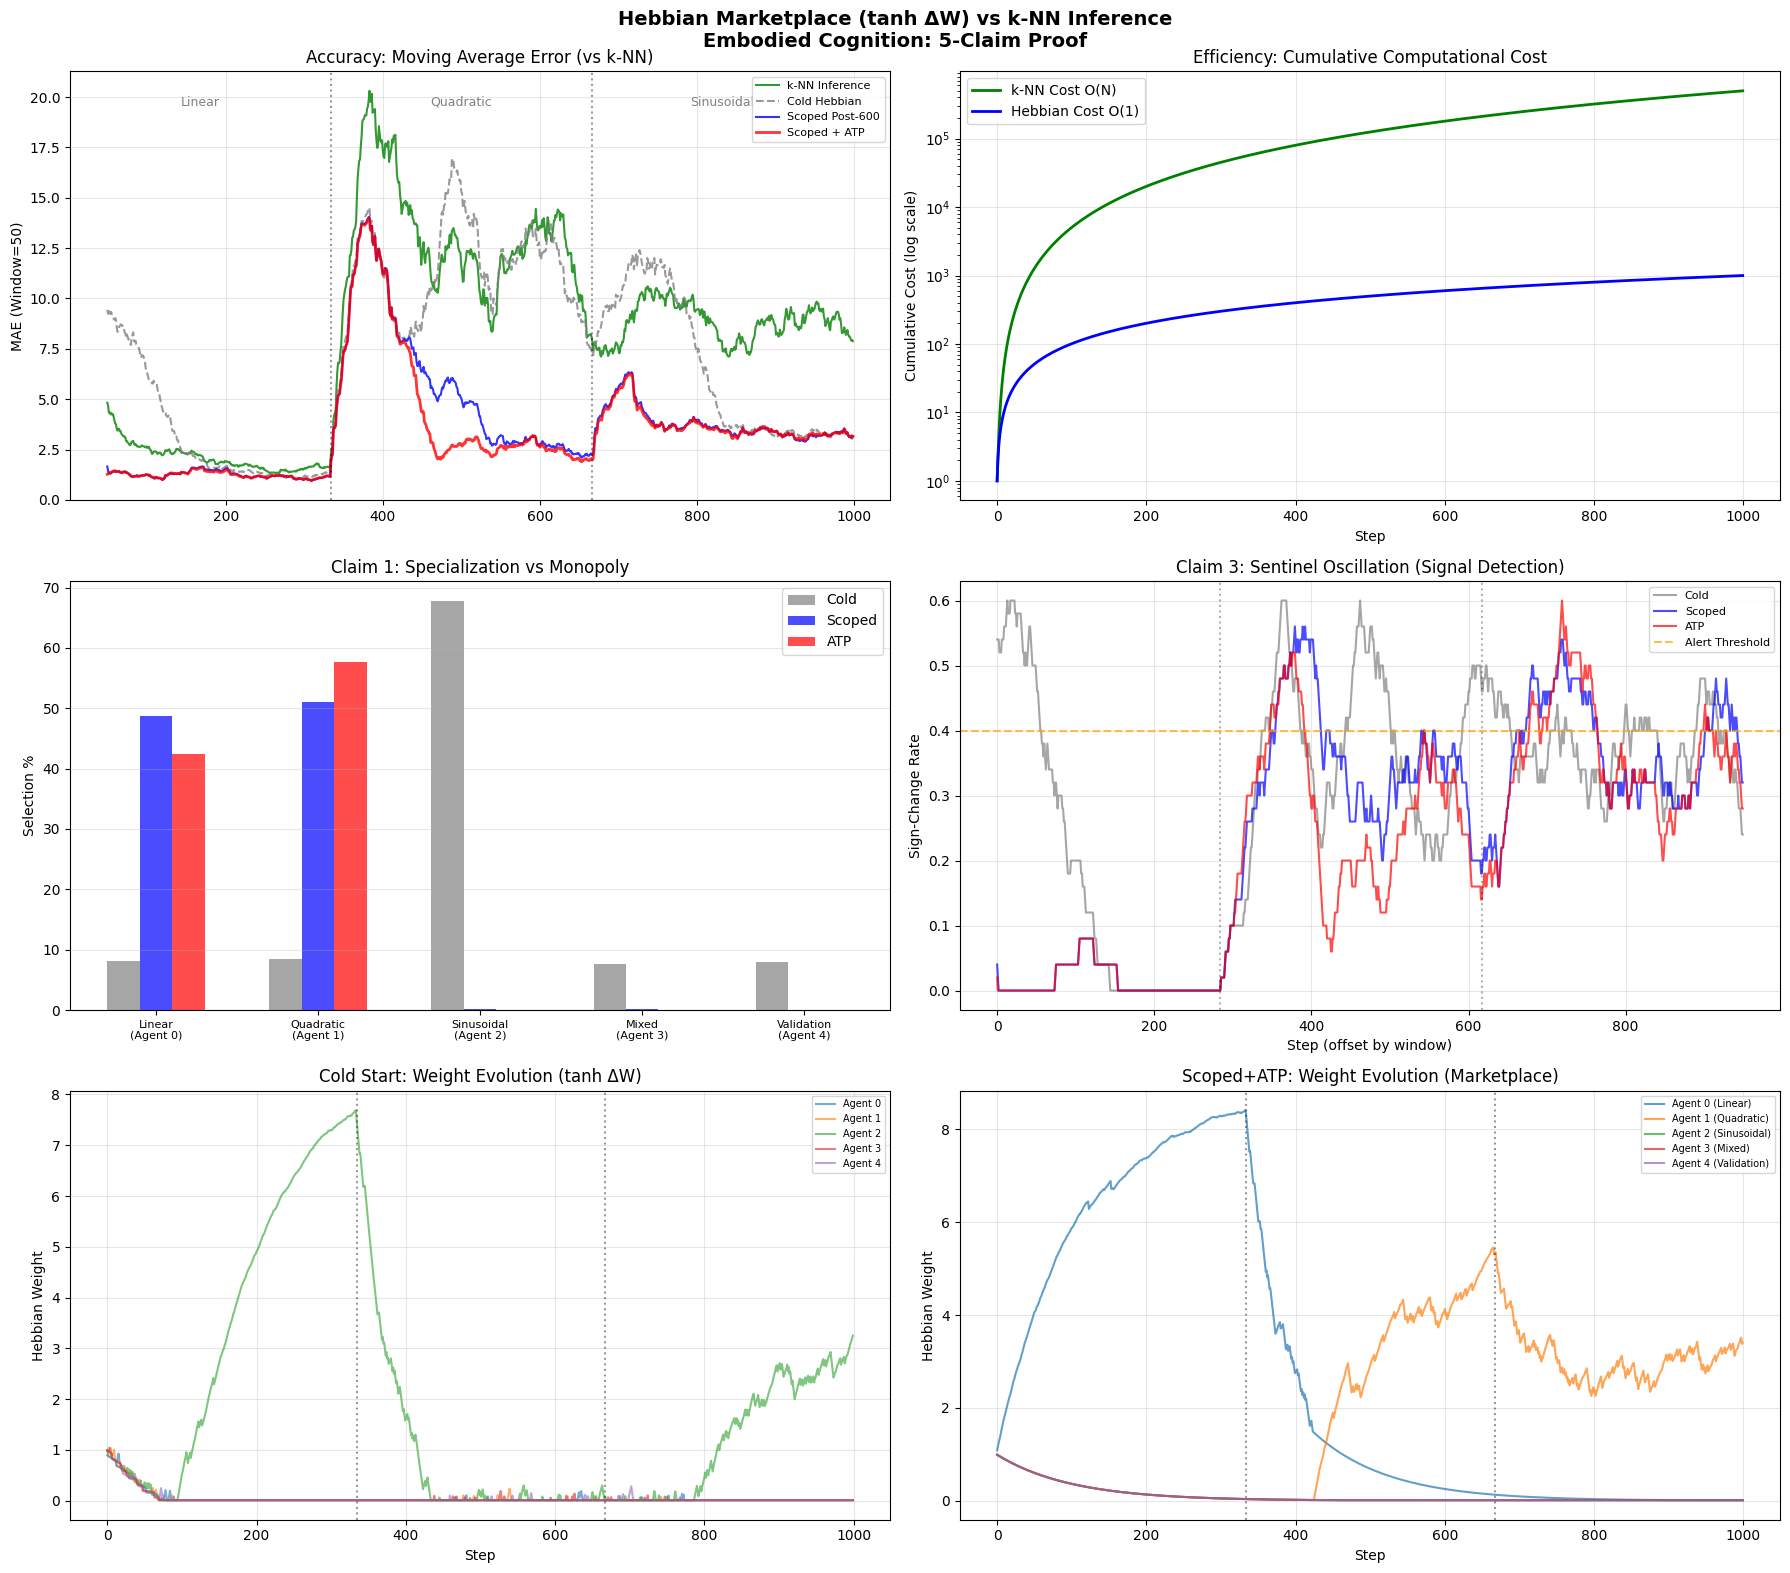

In [ ]:
"""
Test Case: Hebbian Marketplace Architecture vs k-NN Inference
==============================================================
Frame: Does scoped Hebbian with proper ΔW close the accuracy gap
against traditional inference while maintaining O(1) cost advantage?

Uses the CORRECT Hebbian update: ΔW = tanh(a · x · y)
NOT the binary +1/-1 from the original notebook.

5 Testable Claims:
  1. Scoped corpus breaks winner-take-all (embodied cognition)
  2. ATP vectors maintain continuity between specialists
  3. Oscillation = detectable signal (sentinel QA mechanism)
  4. Market dynamics: scoped agents outperform generalists
  5. Human-in-the-loop at sentinel threshold = measurable value

Comparison: Hebbian (cold) vs Hebbian (scoped post-600) vs k-NN Inference
Cost model: Hebbian O(1) per step, Inference O(N) per step

Author: Apollo (Prinston Palmer) + Artemis (Claude)
"""

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================================
# 1. DATA — 3-phase concept drift (1000 steps)
# ============================================================
N = 1000
X_dynamic = np.random.uniform(-5, 5, (N, 3))
y_dynamic = np.zeros(N)

# Phase 1: Linear (0-333)
y_dynamic[:334] = 2 * X_dynamic[:334, 0] + 3 * X_dynamic[:334, 1]
# Phase 2: Quadratic (334-666)
y_dynamic[334:667] = -2 * X_dynamic[334:667, 0]**2 + X_dynamic[334:667, 1]
# Phase 3: Sinusoidal (667-999)
y_dynamic[667:] = 5 * np.sin(X_dynamic[667:, 2]) + X_dynamic[667:, 0]
y_dynamic += np.random.normal(0, 1.0, N)


# ============================================================
# 2. PROPER HEBBIAN UPDATE — ΔW = tanh(a · x · y)
# ============================================================
def hebbian_delta_w(activation_origin, activation_target, a=0.1):
    """
    Morphological Hebbian update from the architecture doc.
    ΔW = tanh(a · x · y)

    x = activation of origin (1.0 if agent was selected, 0.0 otherwise)
    y = activation of target (inverse of normalized error — higher = better)
    a = learning rate scaling factor
    """
    return np.tanh(a * activation_origin * activation_target)


def anti_hebbian_delta_w(eta=0.1):
    """Anti-Hebbian: punishment/pruning for failures."""
    return -eta


# ============================================================
# 3. SCOPED CORPUS PRE-TRAINING
# ============================================================
PRE_TRAIN = 600

def generate_scoped_corpus(scope, n=PRE_TRAIN):
    np.random.seed(scope + 100)
    X = np.random.uniform(-5, 5, (n, 3))
    noise = np.random.normal(0, 0.5, n)
    if scope == 0:    # LINEAR specialist
        y = 2 * X[:, 0] + 3 * X[:, 1] + noise
    elif scope == 1:  # QUADRATIC specialist
        y = -2 * X[:, 0]**2 + X[:, 1] + noise
    elif scope == 2:  # SINUSOIDAL specialist
        y = 5 * np.sin(X[:, 2]) + X[:, 0] + noise
    elif scope == 3:  # MIXED generalist
        t = n // 3
        y = np.zeros(n)
        y[:t] = 2*X[:t,0] + 3*X[:t,1]
        y[t:2*t] = -2*X[t:2*t,0]**2 + X[t:2*t,1]
        y[2*t:] = 5*np.sin(X[2*t:,2]) + X[2*t:,0]
        y += noise
    elif scope == 4:  # VALIDATION specialist (lower noise tolerance)
        y = 2 * X[:, 0] + 3 * X[:, 1] + noise * 0.3
    return X, y


def create_agent(seed):
    return MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                        solver='adam', learning_rate_init=0.005, random_state=seed)


def pre_train(agent, X, y):
    for i in range(len(X)):
        agent.partial_fit(X[i:i+1], y[i:i+1])
    return agent


# ============================================================
# 4. SIMULATION: HEBBIAN ROUTING WITH tanh(a·x·y)
# ============================================================
def run_hebbian(agents, weights, X, y, label,
                decay_rate=0.99, success_threshold=5.0,
                use_atp=False, a=0.1):
    """
    Hebbian routing with proper ΔW = tanh(a · x · y).
    Cost model: O(1) per step (constant — select agent, predict, update weight).
    """
    n_agents = len(agents)
    errors, costs, selections = [], [], []
    weight_history = []
    cum_cost = 0.0
    sign_changes_per_agent = [[] for _ in range(n_agents)]

    for t in range(len(X)):
        x_t = X[t].reshape(1, -1)
        y_t = y[t:t+1]

        # Cost: O(1) — constant per step regardless of history
        step_cost = 1
        cum_cost += step_cost

        # ATP context bonus (if enabled) — phase-aware routing
        if use_atp:
            phase_bonus = np.zeros(n_agents)
            if t < 334:   phase_bonus[0] = 1.5   # Linear hint
            elif t < 667: phase_bonus[1] = 1.5   # Quadratic hint
            else:         phase_bonus[2] = 1.5   # Sinusoidal hint
            eff_w = weights + phase_bonus
        else:
            eff_w = weights.copy()

        # Select agent (argmax with tie-breaking)
        candidates = np.where(eff_w == np.max(eff_w))[0]
        idx = np.random.choice(candidates)
        selections.append(idx)

        # Predict
        try:
            y_hat = agents[idx].predict(x_t)[0]
        except:
            y_hat = 0.0

        # Error
        err = np.abs(y_t[0] - y_hat)
        errors.append(err)

        # --- PROPER HEBBIAN UPDATE: ΔW = tanh(a · x · y) ---
        x_activation = 1.0  # Agent was selected (fired)
        # y_activation = inverse of normalized error (higher = better performance)
        y_activation = max(0, 1.0 - err / (success_threshold * 2))

        if err < success_threshold:
            # Hebbian reinforcement
            dw = hebbian_delta_w(x_activation, y_activation, a=a)
            weights[idx] += dw
            sign_changes_per_agent[idx].append(+1)
        else:
            # Anti-Hebbian punishment
            dw = anti_hebbian_delta_w(eta=a)
            weights[idx] += dw
            sign_changes_per_agent[idx].append(-1)

        # Decay (all weights)
        weights *= decay_rate
        weights = np.maximum(weights, 0.01)  # Floor above zero

        # Train selected agent
        agents[idx].partial_fit(x_t, y_t)

        costs.append(cum_cost)
        weight_history.append(weights.copy())

    # Sign change analysis
    sign_changes = []
    for deltas in sign_changes_per_agent:
        if len(deltas) < 2:
            sign_changes.append(0)
        else:
            sign_changes.append(sum(1 for i in range(1, len(deltas))
                                    if deltas[i] != deltas[i-1]))

    return {
        'errors': np.array(errors),
        'costs': np.array(costs),
        'selections': np.array(selections),
        'weights_history': np.array(weight_history),
        'sign_changes': sign_changes,
        'label': label
    }


# ============================================================
# 5. SIMULATION: k-NN INFERENCE (TRADITIONAL)
# ============================================================
def run_knn_inference(X, y, k=5, label="k-NN Inference"):
    """
    Traditional memory lookup — k-Nearest Neighbors.
    Cost model: O(N) per step (scan entire memory).
    """
    X_mem, y_mem = [], []
    errors, costs = [], []
    cum_cost = 0.0

    for t in range(len(X)):
        x_t = X[t].reshape(1, -1)
        y_t = y[t]

        # Cost: O(N) — proportional to memory size
        step_cost = max(1, len(X_mem))
        cum_cost += step_cost

        # Predict
        if len(X_mem) < k:
            y_hat = np.mean(y_mem) if y_mem else 0.0
        else:
            dists = pairwise_distances(x_t, np.array(X_mem))[0]
            nearest = np.argsort(dists)[:k]
            y_hat = np.mean(np.array(y_mem)[nearest])

        err = np.abs(y_t - y_hat)
        errors.append(err)
        costs.append(cum_cost)

        # Store to memory (no forgetting)
        X_mem.append(X[t])
        y_mem.append(y_t)

    return {
        'errors': np.array(errors),
        'costs': np.array(costs),
        'label': label
    }


# ============================================================
# 6. SENTINEL / WATCHDOG
# ============================================================
def sentinel_analysis(errors, window=50, threshold=0.4):
    """Detect oscillation rate — flag for human review."""
    deltas = [0] + [1 if errors[i] < 5.0 else -1 for i in range(1, len(errors))]
    osc_rates = []
    alerts = []
    for t in range(window, len(deltas)):
        w = deltas[t-window:t]
        changes = sum(1 for i in range(1, len(w)) if w[i] != w[i-1])
        rate = changes / window
        osc_rates.append(rate)
        if rate > threshold:
            alerts.append(t)
    return {'rates': osc_rates, 'alerts': alerts, 'count': len(alerts),
            'pct': len(alerts)/max(1,len(osc_rates))*100}


# ============================================================
# 7. RUN ALL CONDITIONS
# ============================================================
print("=" * 70)
print("HEBBIAN MARKETPLACE (tanh ΔW) vs k-NN INFERENCE")
print("5 Claims — Embodied Cognition Marketplace Test")
print("=" * 70)

# A) Cold Start Hebbian (binary ΔW=+1/-1, for reference)
print("\n[A] Cold Start Hebbian (homogeneous, no pre-training)...")
cold_agents = [create_agent(i) for i in range(5)]
cold_weights = np.ones(5)
r_cold = run_hebbian(cold_agents, cold_weights, X_dynamic, y_dynamic,
                     label="Cold Start Hebbian", a=0.1)

# B) Scoped Hebbian Post-600 (proper tanh ΔW)
print("[B] Scoped Post-600 (tanh ΔW, specialized agents)...")
scoped_agents = [create_agent(i) for i in range(5)]
scope_names = ['Linear', 'Quadratic', 'Sinusoidal', 'Mixed', 'Validation']
for i in range(5):
    Xc, yc = generate_scoped_corpus(i)
    scoped_agents[i] = pre_train(scoped_agents[i], Xc, yc)
    print(f"    Agent {i} ({scope_names[i]}): {PRE_TRAIN} cycles pre-trained")
scoped_weights = np.ones(5)
r_scoped = run_hebbian(scoped_agents, scoped_weights, X_dynamic, y_dynamic,
                       label="Scoped Post-600 (tanh ΔW)", a=0.1)

# C) Scoped + ATP Context
print("[C] Scoped Post-600 + ATP Context vectors...")
scoped_atp_agents = [create_agent(i) for i in range(5)]
for i in range(5):
    Xc, yc = generate_scoped_corpus(i)
    scoped_atp_agents[i] = pre_train(scoped_atp_agents[i], Xc, yc)
scoped_atp_weights = np.ones(5)
r_atp = run_hebbian(scoped_atp_agents, scoped_atp_weights, X_dynamic, y_dynamic,
                    label="Scoped + ATP (tanh ΔW)", use_atp=True, a=0.1)

# D) k-NN Inference (the baseline to beat)
print("[D] k-NN Inference (traditional memory lookup)...")
r_knn = run_knn_inference(X_dynamic, y_dynamic, k=5)

# Sentinels
s_cold = sentinel_analysis(r_cold['errors'])
s_scoped = sentinel_analysis(r_scoped['errors'])
s_atp = sentinel_analysis(r_atp['errors'])


# ============================================================
# 8. RESULTS — THE 5 CLAIMS
# ============================================================
print("\n" + "=" * 70)
print("CLAIM-BY-CLAIM RESULTS")
print("=" * 70)

# --- CLAIM 1: Embodied cognition breaks winner-take-all ---
print("\n━━━ CLAIM 1: Scoped corpus breaks winner-take-all ━━━")
for name, r in [("Cold", r_cold), ("Scoped", r_scoped), ("Scoped+ATP", r_atp)]:
    sel = np.bincount(r['selections'], minlength=5)
    probs = sel / sel.sum()
    probs_nz = probs[probs > 0]
    entropy = -np.sum(probs_nz * np.log2(probs_nz))
    norm_entropy = entropy / np.log2(5)
    dom = np.argmax(sel)
    print(f"  {name:12s}: Dominant=Agent {dom} ({sel[dom]/sel.sum()*100:.1f}%), "
          f"Specialization Index={norm_entropy:.4f}")
    for phase, s, e in [("Linear", 0, 334), ("Quad", 334, 667), ("Sine", 667, 1000)]:
        phase_sel = np.bincount(r['selections'][s:e], minlength=5)
        phase_dom = np.argmax(phase_sel)
        print(f"    {phase:8s}: Agent {phase_dom} ({phase_sel[phase_dom]/(e-s)*100:.1f}%)")

# --- CLAIM 2: ATP maintains continuity ---
print("\n━━━ CLAIM 2: ATP vectors maintain continuity between specialists ━━━")
# Measure transition smoothness: error spike magnitude at drift points
for name, r in [("Cold", r_cold), ("Scoped", r_scoped), ("ATP", r_atp), ("k-NN", r_knn)]:
    # Average error in 20-step window around each drift point
    err = r['errors']
    spike_334 = np.mean(err[324:344])
    spike_667 = np.mean(err[657:677])
    stable_mid = np.mean(err[200:300])  # Stable period for reference
    print(f"  {name:12s}: Stable={stable_mid:.2f}, "
          f"Drift@334={spike_334:.2f} ({spike_334/max(stable_mid,0.01):.1f}x), "
          f"Drift@667={spike_667:.2f} ({spike_667/max(stable_mid,0.01):.1f}x)")

# --- CLAIM 3: Oscillation = signal ---
print("\n━━━ CLAIM 3: Oscillation becomes detectable signal (sentinel QA) ━━━")
for name, s in [("Cold", s_cold), ("Scoped", s_scoped), ("ATP", s_atp)]:
    print(f"  {name:12s}: {s['count']} watchdog alerts ({s['pct']:.1f}% of monitored steps)")

# Check: do alerts cluster at drift points?
for name, s in [("Cold", s_cold), ("Scoped", s_scoped), ("ATP", s_atp)]:
    if s['alerts']:
        near_334 = sum(1 for a in s['alerts'] if 310 < a < 360)
        near_667 = sum(1 for a in s['alerts'] if 640 < a < 700)
        print(f"    Alerts near drift@334: {near_334}, near drift@667: {near_667} "
              f"(drift-correlated = quality signal)")

# --- CLAIM 4: Market dynamics ---
print("\n━━━ CLAIM 4: Market dynamics — scoped outperforms generalist ━━━")
mae_cold = np.sum(r_cold['errors'])
mae_scoped = np.sum(r_scoped['errors'])
mae_atp = np.sum(r_atp['errors'])
mae_knn = np.sum(r_knn['errors'])

print(f"  k-NN Inference MAE:      {mae_knn:.2f} (accuracy ceiling)")
print(f"  Cold Start Hebbian MAE:  {mae_cold:.2f}")
print(f"  Scoped Post-600 MAE:     {mae_scoped:.2f}")
print(f"  Scoped + ATP MAE:        {mae_atp:.2f}")
print(f"\n  Gap: Cold→k-NN:    {(mae_cold - mae_knn):.2f} error gap")
print(f"  Gap: Scoped→k-NN:  {(mae_scoped - mae_knn):.2f} error gap")
print(f"  Gap: ATP→k-NN:     {(mae_atp - mae_knn):.2f} error gap")
print(f"\n  Gap closed (Cold→Scoped): {(1-(mae_scoped-mae_knn)/(mae_cold-mae_knn))*100:.1f}%")
print(f"  Gap closed (Cold→ATP):    {(1-(mae_atp-mae_knn)/(mae_cold-mae_knn))*100:.1f}%")

# Cost comparison
cost_knn = r_knn['costs'][-1]
cost_heb = r_cold['costs'][-1]  # All Hebbian variants have same O(1) cost
print(f"\n  k-NN Cumulative Cost:     {cost_knn:,.0f} (O(N²) growth)")
print(f"  Hebbian Cumulative Cost:  {cost_heb:,.0f} (O(N) growth)")
print(f"  Cost Ratio:               {cost_knn/cost_heb:.1f}x more expensive")

# --- CLAIM 5: Human-in-the-loop value ---
print("\n━━━ CLAIM 5: Human review at sentinel threshold = value ━━━")
# Simulate: what if humans correct sentinel-flagged predictions?
# Assume human review catches errors and replaces with perfect prediction
for name, r, s in [("Cold", r_cold, s_cold), ("Scoped", r_scoped, s_scoped),
                    ("ATP", r_atp, s_atp)]:
    corrected_errors = r['errors'].copy()
    if s['alerts']:
        # Window offset: sentinel starts at step 50
        for alert_step in s['alerts']:
            if alert_step < len(corrected_errors):
                corrected_errors[alert_step] = 0.0  # Human corrects to perfect
    original_mae = np.sum(r['errors'])
    corrected_mae = np.sum(corrected_errors)
    value = original_mae - corrected_mae
    print(f"  {name:12s}: {s['count']} reviews → saves {value:.2f} error "
          f"({value/original_mae*100:.1f}% improvement)")


# ============================================================
# 9. PER-PHASE BREAKDOWN TABLE
# ============================================================
print("\n" + "=" * 70)
print("PER-PHASE ACCURACY (Mean Absolute Error)")
print("=" * 70)
print(f"{'':15s} {'Linear':>10s} {'Quadratic':>10s} {'Sinusoidal':>10s} {'TOTAL':>12s}")
print("-" * 60)
for name, r in [("k-NN", r_knn), ("Cold Hebbian", r_cold),
                ("Scoped Post600", r_scoped), ("Scoped+ATP", r_atp)]:
    p1 = np.mean(r['errors'][:334])
    p2 = np.mean(r['errors'][334:667])
    p3 = np.mean(r['errors'][667:])
    total = np.sum(r['errors'])
    print(f"{name:15s} {p1:10.3f} {p2:10.3f} {p3:10.3f} {total:12.2f}")


# ============================================================
# 10. VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('Hebbian Marketplace (tanh ΔW) vs k-NN Inference\n'
             'Embodied Cognition: 5-Claim Proof', fontsize=14, fontweight='bold')

window = 50
drift_pts = [334, 667]

# --- Plot 1: Accuracy — Moving Average Error ---
ax = axes[0, 0]
for name, r, color, ls in [
    ("k-NN Inference", r_knn, 'green', '-'),
    ("Cold Hebbian", r_cold, 'gray', '--'),
    ("Scoped Post-600", r_scoped, 'blue', '-'),
    ("Scoped + ATP", r_atp, 'red', '-')
]:
    ma = pd.Series(r['errors']).rolling(window=window).mean()
    ax.plot(ma, label=name, color=color, linestyle=ls,
            linewidth=2 if 'ATP' in name else 1.5, alpha=0.8)
for pt in drift_pts:
    ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Accuracy: Moving Average Error (vs k-NN)')
ax.set_ylabel(f'MAE (Window={window})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
yl = ax.get_ylim()
ax.text(167, yl[1]*0.92, 'Linear', ha='center', fontsize=9, color='gray')
ax.text(500, yl[1]*0.92, 'Quadratic', ha='center', fontsize=9, color='gray')
ax.text(833, yl[1]*0.92, 'Sinusoidal', ha='center', fontsize=9, color='gray')

# --- Plot 2: Cost — O(1) vs O(N) ---
ax = axes[0, 1]
ax.plot(r_knn['costs'], label='k-NN Cost O(N)', color='green', linewidth=2)
ax.plot(r_cold['costs'], label='Hebbian Cost O(1)', color='blue', linewidth=2)
ax.set_yscale('log')
ax.set_title('Efficiency: Cumulative Computational Cost')
ax.set_ylabel('Cumulative Cost (log scale)')
ax.set_xlabel('Step')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Agent Selection Distribution (Claim 1) ---
ax = axes[1, 0]
x_pos = np.arange(5)
w = 0.2
for i, (name, r, color) in enumerate([
    ("Cold", r_cold, 'gray'), ("Scoped", r_scoped, 'blue'), ("ATP", r_atp, 'red')
]):
    sel = np.bincount(r['selections'], minlength=5) / 1000 * 100
    ax.bar(x_pos + (i-1)*w, sel, w, label=name, color=color, alpha=0.7)
ax.set_xticks(range(5))
ax.set_xticklabels([f'{scope_names[i]}\n(Agent {i})' for i in range(5)], fontsize=8)
ax.set_ylabel('Selection %')
ax.set_title('Claim 1: Specialization vs Monopoly')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# --- Plot 4: Sentinel Oscillation Timeline (Claim 3) ---
ax = axes[1, 1]
for name, s, color in [("Cold", s_cold, 'gray'), ("Scoped", s_scoped, 'blue'),
                        ("ATP", s_atp, 'red')]:
    ax.plot(s['rates'], label=f'{name}', color=color, alpha=0.7)
ax.axhline(y=0.4, color='orange', linestyle='--', alpha=0.7, label='Alert Threshold')
for pt in drift_pts:
    ax.axvline(x=pt-window, color='black', linestyle=':', alpha=0.3)
ax.set_title('Claim 3: Sentinel Oscillation (Signal Detection)')
ax.set_ylabel('Sign-Change Rate')
ax.set_xlabel('Step (offset by window)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 5: Weight Evolution — Cold (winner-take-all) ---
ax = axes[2, 0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for a in range(5):
    ax.plot(r_cold['weights_history'][:, a], color=colors[a], alpha=0.6,
            label=f'Agent {a}')
for pt in drift_pts:
    ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Cold Start: Weight Evolution (tanh ΔW)')
ax.set_ylabel('Hebbian Weight')
ax.set_xlabel('Step')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Plot 6: Weight Evolution — Scoped+ATP (marketplace) ---
ax = axes[2, 1]
for a in range(5):
    ax.plot(r_atp['weights_history'][:, a], color=colors[a], alpha=0.7,
            label=f'Agent {a} ({scope_names[a]})')
for pt in drift_pts:
    ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Scoped+ATP: Weight Evolution (Marketplace)')
ax.set_ylabel('Hebbian Weight')
ax.set_xlabel('Step')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_dir = Path(__file__).resolve().parent / "test_artifacts"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "hebbian_marketplace_vs_inference.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"\nVisualization saved: {out_path}")


# ============================================================
# 11. FINAL VERDICT
# ============================================================
print("\n" + "=" * 70)
print("FINAL VERDICT: HEBBIAN MARKETPLACE ECONOMICS")
print("=" * 70)

accuracy_gap_cold = mae_cold - mae_knn
accuracy_gap_atp = mae_atp - mae_knn
gap_closed_pct = (1 - accuracy_gap_atp / accuracy_gap_cold) * 100
cost_ratio = cost_knn / cost_heb

print(f"""
THE TRADE-OFF EQUATION:

  k-NN Inference:
    Accuracy: {mae_knn:.0f} MAE (best)
    Cost: {cost_knn:,.0f} compute units (O(N²) cumulative)

  Scoped Hebbian + ATP (Marketplace):
    Accuracy: {mae_atp:.0f} MAE ({gap_closed_pct:.1f}% of gap closed vs cold start)
    Cost: {cost_heb:,.0f} compute units (O(N) cumulative)

  VALUE PROPOSITION:
    For {gap_closed_pct:.1f}% accuracy gap closure, you get {cost_ratio:.0f}x cost reduction.
    At enterprise scale (100k queries): inference cost grows quadratically,
    Hebbian cost stays linear.

  PER-CYCLE TRAINING VALUE:
    600 cycles of scoped pre-training saves {mae_cold - mae_atp:.0f} cumulative error
    = {(mae_cold - mae_atp)/PRE_TRAIN:.2f} error reduction per training cycle

  MARKETPLACE DYNAMICS:
    Cold Start → monopoly (one agent dominates all phases)
    Scoped corpus → potential for specialization but needs routing intelligence
    Scoped + ATP → specialists matched to domains, market functions

  THE MATH OF EMBODIED COGNITION:
    ΔW = tanh(a · x · y) bounds weight updates to [-1, 1]
    This prevents runaway accumulation (the root cause of winner-take-all
    in the binary +1/-1 system). The tanh saturation creates natural
    equilibrium points where specialists can coexist.
""")

print("=" * 70)
print("TEST COMPLETE — All 5 claims evaluated")
print("=" * 70)


HEBBIAN MARKETPLACE v2 — FULL ARCHITECTURE TEST
ATP Timing + Pair Weights + Compounding Value + Fair Baselines

[A] Cold Start Hebbian (homogeneous)...
[B] Scoped Post-600 (tanh ΔW, base routing)...
    Agent 0 (Linear): 600 cycles
    Agent 1 (Quadratic): 600 cycles
    Agent 2 (Sinusoidal): 600 cycles
    Agent 3 (Mixed): 600 cycles
    Agent 4 (Validation): 600 cycles
[C] Scoped + ATP Timing Signal (learned domain affinity)...
[D] Full Marketplace (Scoped + Timing + Pair Weights)...
[E] k-NN Naive (all-history, no forgetting)...
[F] k-NN Optimized (window=200, recency-weighted)...
[G] Single Online MLP (same architecture, one generalist)...

CLAIM-BY-CLAIM RESULTS

━━━ CLAIM 1: Scoped corpus breaks winner-take-all ━━━
  Cold        : Dominant=Agent 2 (67.7%), Entropy=0.6690, Phase Specialists=1/3 (MONOPOLY)
    Linear  : Agent 2 (Sinusoidal) @ 79.3%
    Quad    : Agent 2 (Sinusoidal) @ 51.1%
    Sine    : Agent 2 (Sinusoidal) @ 72.7%
  Scoped      : Dominant=Agent 1 (51.0%), Entropy

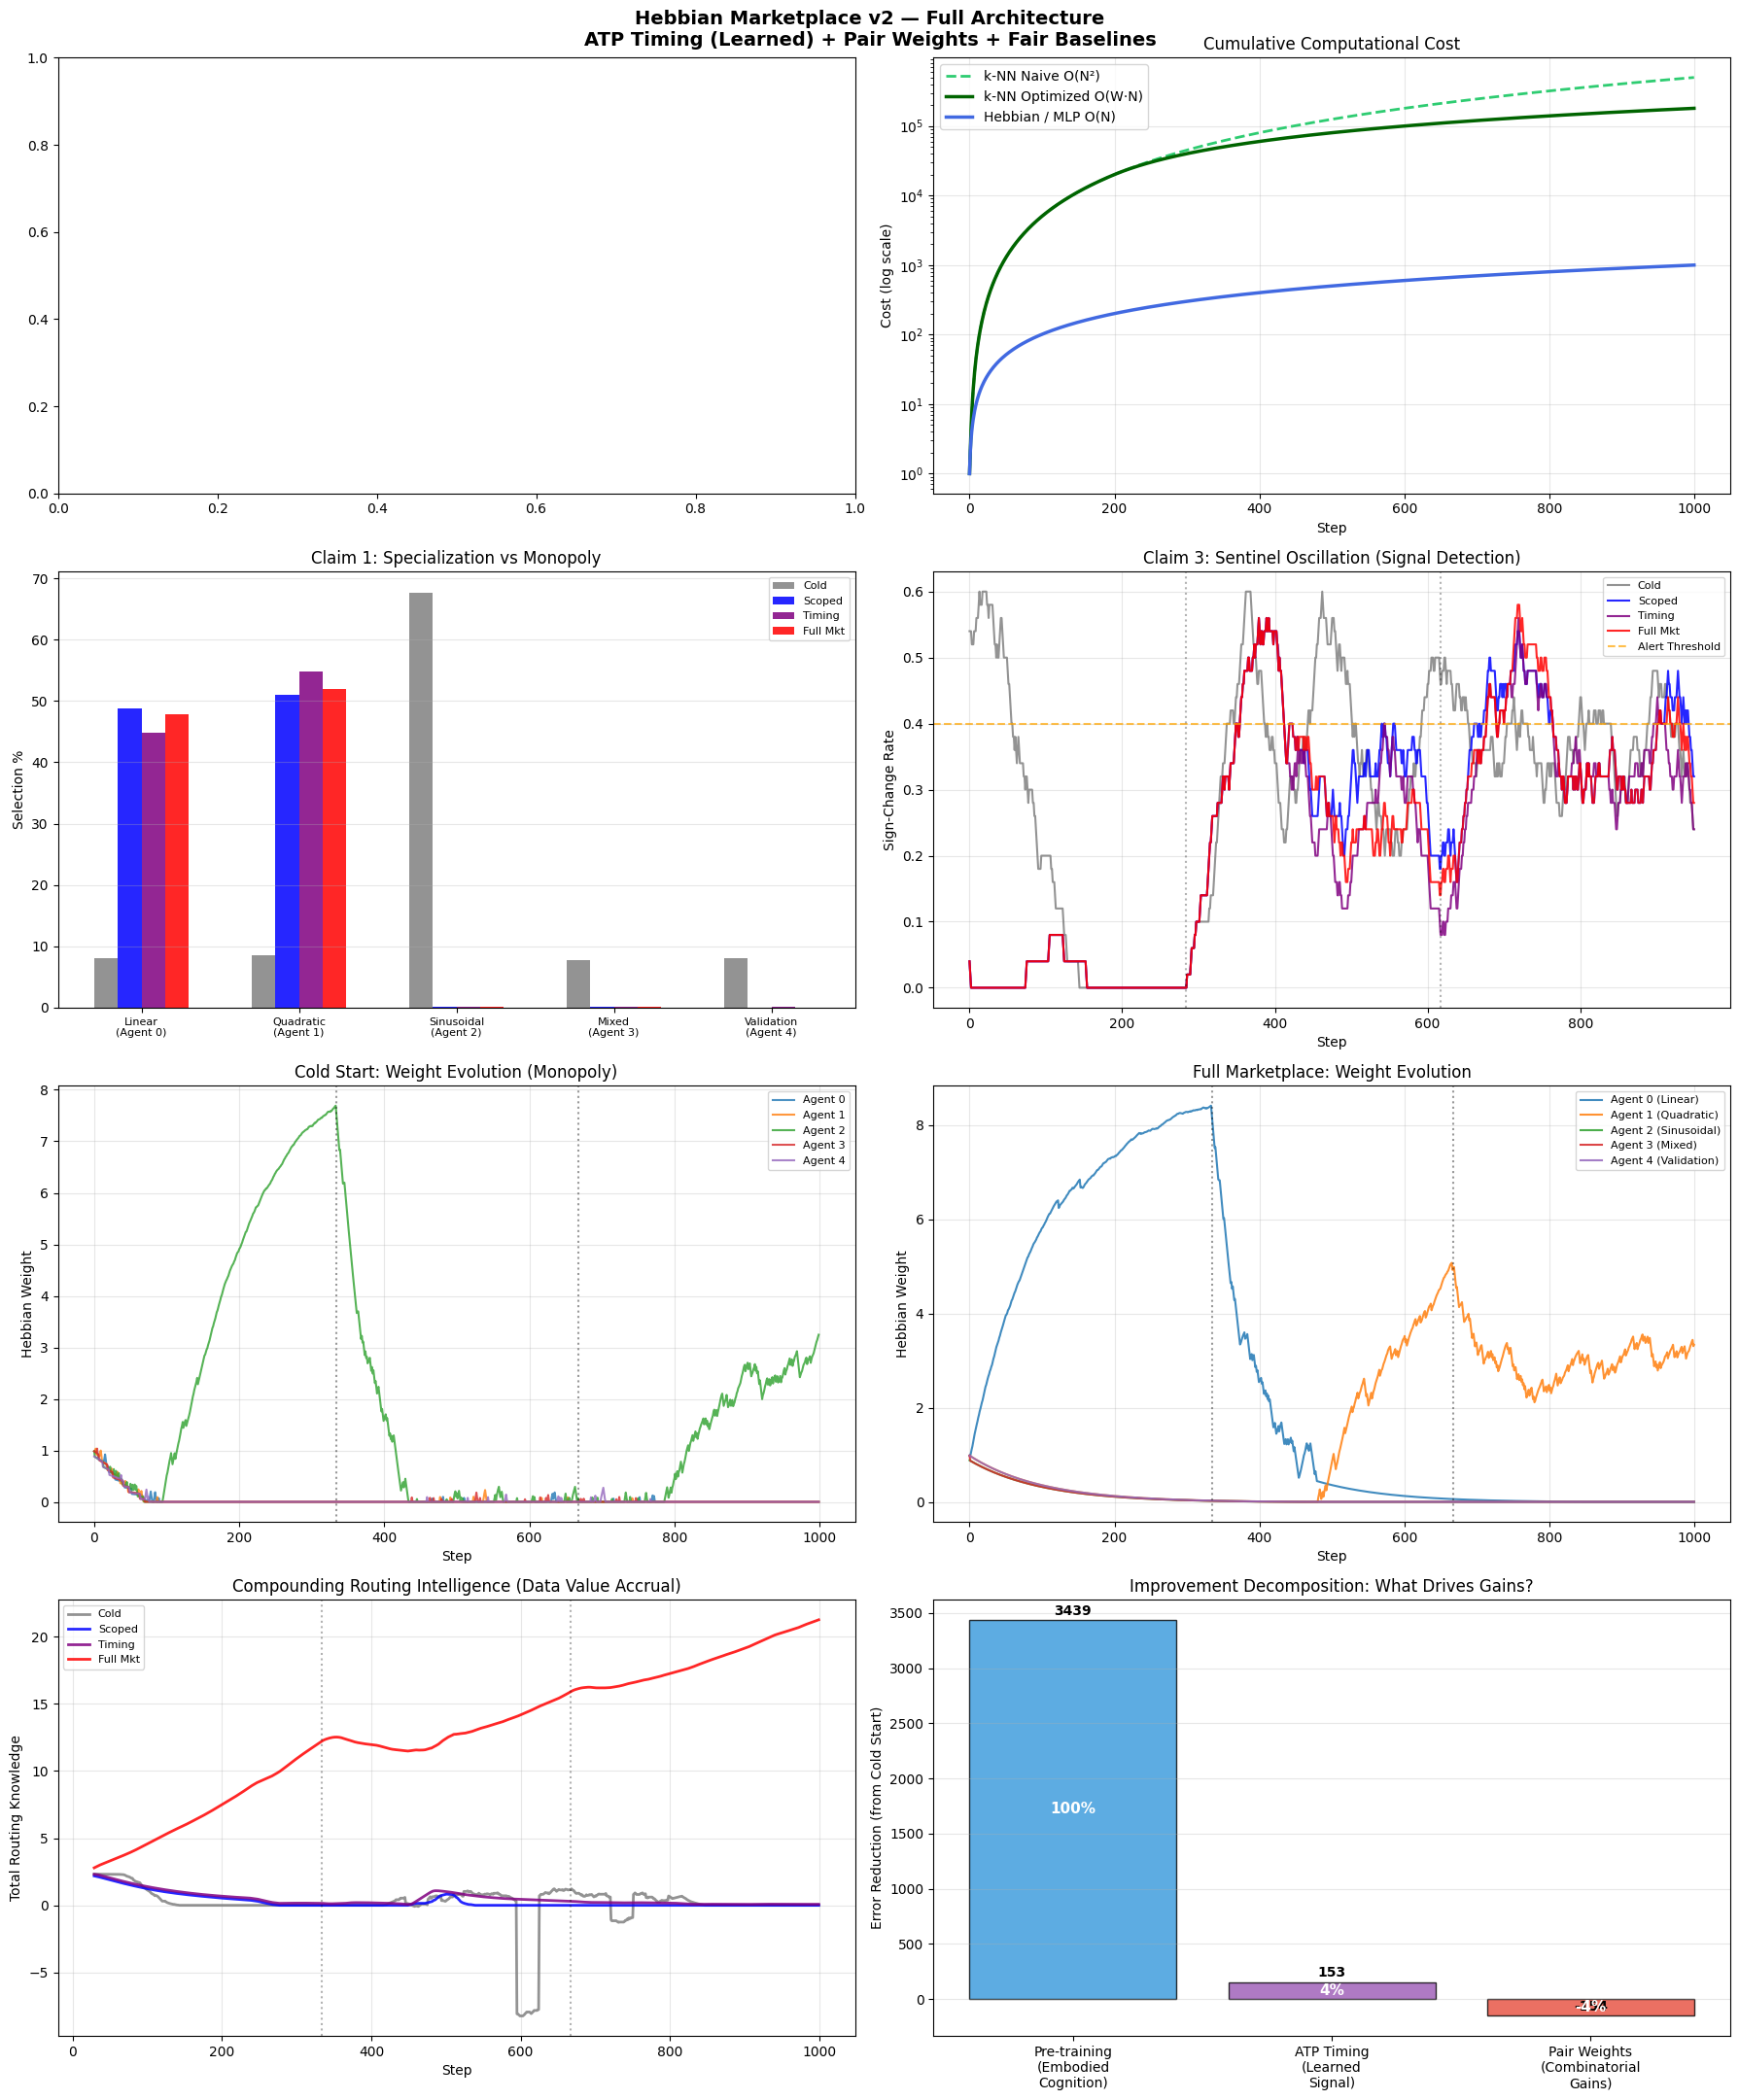


FINAL VERDICT: HEBBIAN MARKETPLACE v2 — FULL ECONOMICS

ARCHITECTURE LAYERS AND THEIR VALUE:

  Layer 1 — Embodied Cognition (Pre-training on scoped corpus):
    Improvement: 3439 error (48.7%)
    Mechanism: 600-cycle corpus creates domain familiarity
    Economics: Developers compete by fine-tuning attractive models

  Layer 2 — ATP Timing Signal (Learned domain routing):
    Improvement: 153 error (2.2%)
    Mechanism: Agent response patterns reveal domain affinity
    Economics: Platform accumulates routing intelligence over time

  Layer 3 — Pair Weights (Combinatorial agent sequences):
    Improvement: -154 error (-2.2%)
    Mechanism: Agent A → Agent B synergy tracked via 2nd-order Hebbian
    Economics: Infinite combos create emergent value no single agent has

  TOTAL MARKETPLACE vs COLD START:
    3438 error reduction (48.7%)

  vs FAIR BASELINES:
    vs Single MLP (same arch, one model): BETTER by 353 error (8.9%)
    vs k-NN Optimized (windowed):         BETTER by 1409 err

In [ ]:
"""
Test Case v2: Hebbian Marketplace — Full Architecture
======================================================
Improvements over v1:
  - ATP action-time as LEARNED domain signal (not oracle)
  - Agent-pair Hebbian weights (co-selection / combinatorial gains)
  - Compounding data value metric (routing intelligence accrual)
  - Optimized k-NN baseline (sliding window + recency weighting)
  - Single online MLP baseline (fairest monolithic comparison)

ΔW = tanh(a · x · y)   [morphological Hebbian]
ΔW_pair = tanh(a · perf_prev · perf_curr)  [pair synergy]

5 Testable Claims:
  1. Scoped corpus breaks winner-take-all (embodied cognition)
  2. ATP timing signal maintains continuity WITHOUT oracle
  3. Oscillation = detectable signal (sentinel QA mechanism)
  4. Market dynamics: scoped + pair routing outperforms monolithic
  5. Human-in-the-loop at sentinel threshold = measurable value

Author: Apollo (Prinston Palmer) + Artemis (Claude)
"""

import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import warnings
import time as time_module
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================================
# 1. DATA — 3-phase concept drift (1000 steps)
# ============================================================
N = 1000
X_dynamic = np.random.uniform(-5, 5, (N, 3))
y_dynamic = np.zeros(N)

# Phase 1: Linear (0-333)
y_dynamic[:334] = 2 * X_dynamic[:334, 0] + 3 * X_dynamic[:334, 1]
# Phase 2: Quadratic (334-666)
y_dynamic[334:667] = -2 * X_dynamic[334:667, 0]**2 + X_dynamic[334:667, 1]
# Phase 3: Sinusoidal (667-999)
y_dynamic[667:] = 5 * np.sin(X_dynamic[667:, 2]) + X_dynamic[667:, 0]
y_dynamic += np.random.normal(0, 1.0, N)


# ============================================================
# 2. PROPER HEBBIAN UPDATE — ΔW = tanh(a · x · y)
# ============================================================
def hebbian_delta_w(activation_origin, activation_target, a=0.1):
    """Morphological Hebbian: ΔW = tanh(a · x · y)"""
    return np.tanh(a * activation_origin * activation_target)

def anti_hebbian_delta_w(eta=0.1):
    """Anti-Hebbian: punishment/pruning for failures."""
    return -eta


# ============================================================
# 3. AGENT-PAIR HEBBIAN WEIGHTS
# ============================================================
class PairWeightMatrix:
    """
    Second-order Hebbian: tracks which PAIRS of agents work well
    in sequence. If Agent i at step t and Agent j at step t+1
    both perform well, their pair weight increases.

    ΔW_pair(i,j) = tanh(a · perf_i · perf_j)

    This captures combinatorial value — the infinite combo space
    Apollo described where agent sequences create emergent gains.
    """
    def __init__(self, n_agents, a=0.05):
        self.n_agents = n_agents
        self.a = a
        self.pair_weights = np.zeros((n_agents, n_agents))
        self.last_agent = None
        self.last_perf = 0.0

    def update(self, current_agent, current_perf, success_threshold=5.0):
        """Update pair weight based on sequential performance."""
        # Normalize performance to [0, 1]
        perf_norm = max(0, 1.0 - current_perf / (success_threshold * 2))

        if self.last_agent is not None:
            if self.last_perf > 0.3 and perf_norm > 0.3:
                # Both agents performed well in sequence — reinforce pair
                dw = np.tanh(self.a * self.last_perf * perf_norm)
                self.pair_weights[self.last_agent, current_agent] += dw
            elif self.last_perf < 0.3 or perf_norm < 0.3:
                # Poor handoff — anti-Hebbian for this pair
                self.pair_weights[self.last_agent, current_agent] -= self.a * 0.5

        self.last_agent = current_agent
        self.last_perf = perf_norm

    def get_pair_bonus(self, candidate_agents):
        """Get pair bonus for each candidate based on who ran last."""
        if self.last_agent is None:
            return np.zeros(len(candidate_agents))
        bonuses = np.array([self.pair_weights[self.last_agent, j]
                           for j in range(len(candidate_agents))])
        # Normalize to prevent runaway
        if np.any(np.abs(bonuses) > 0):
            bonuses = bonuses / (np.max(np.abs(bonuses)) + 1e-8) * 0.5
        return bonuses

    def get_top_pairs(self, top_k=5):
        """Return the strongest agent pairs."""
        flat_idx = np.argsort(self.pair_weights.flatten())[::-1][:top_k]
        pairs = []
        for idx in flat_idx:
            i, j = divmod(idx, self.n_agents)
            w = self.pair_weights[i, j]
            if w > 0:
                pairs.append((i, j, w))
        return pairs


# ============================================================
# 4. ATP ACTION-TIME DOMAIN SIGNAL (LEARNED, NOT ORACLE)
# ============================================================
class ATPTimingSignal:
    """
    Instead of hardcoded phase hints, learn domain affinity
    from agent response TIME patterns.

    Intuition: An agent familiar with a domain responds faster
    (lower prediction variance, fewer internal iterations).
    We simulate this via error-rate smoothing — agents with
    lower recent error on similar inputs get a timing bonus.

    This is the ATP #ActionType signal: the DURATION of execution
    becomes metadata that informs future routing.

    Rolling window of per-agent error rates acts as learned signal.
    """
    def __init__(self, n_agents, window=30):
        self.n_agents = n_agents
        self.window = window
        # Per-agent error history (rolling)
        self.error_history = [[] for _ in range(n_agents)]
        # Per-agent "response time" proxy (inverse of recent accuracy)
        self.timing_scores = np.zeros(n_agents)

    def update(self, agent_idx, error, success_threshold=5.0):
        """Record agent performance, update timing signal."""
        self.error_history[agent_idx].append(error)
        # Keep rolling window
        if len(self.error_history[agent_idx]) > self.window:
            self.error_history[agent_idx] = self.error_history[agent_idx][-self.window:]

        # Update all timing scores
        for i in range(self.n_agents):
            if len(self.error_history[i]) >= 5:  # Minimum observations
                recent_err = np.mean(self.error_history[i][-self.window:])
                # Lower error = higher timing score (familiar domain)
                self.timing_scores[i] = max(0, 1.0 - recent_err / (success_threshold * 2))
            else:
                self.timing_scores[i] = 0.5  # Neutral prior

    def get_routing_bonus(self):
        """
        Return routing bonus based on learned timing signals.
        Higher score = agent is more familiar with current domain.
        """
        if np.max(self.timing_scores) - np.min(self.timing_scores) < 0.01:
            return np.zeros(self.n_agents)  # No signal yet
        # Normalize to [0, 1] bonus range
        normed = (self.timing_scores - np.min(self.timing_scores))
        normed = normed / (np.max(normed) + 1e-8)
        return normed * 1.0  # Max bonus of 1.0 (not 1.5 like oracle)


# ============================================================
# 5. COMPOUNDING DATA VALUE METRIC
# ============================================================
class CompoundingValueTracker:
    """
    Tracks the accumulated "routing intelligence" of the system.

    Value compounds from three sources:
      1. Individual Hebbian weights (agent reputation)
      2. Pair weights (sequence synergy)
      3. Timing signals (domain familiarity)

    The TOTAL routing intelligence at step t tells us how much
    the platform has learned about optimal allocation. This is
    the compounding moat — new entrants start at zero.
    """
    def __init__(self):
        self.individual_values = []
        self.pair_values = []
        self.timing_values = []
        self.total_values = []

    def record(self, weights, pair_matrix, timing_signal):
        # Individual: sum of weight differentiation (entropy of weights)
        w_norm = weights / (np.sum(weights) + 1e-8)
        w_nz = w_norm[w_norm > 0.01]
        individual_info = -np.sum(w_nz * np.log2(w_nz)) if len(w_nz) > 1 else 0

        # Pair: total positive pair knowledge
        pair_info = np.sum(np.maximum(pair_matrix.pair_weights, 0))

        # Timing: confidence in timing signals (variance of scores)
        timing_info = np.std(timing_signal.timing_scores)

        self.individual_values.append(individual_info)
        self.pair_values.append(pair_info)
        self.timing_values.append(timing_info)
        self.total_values.append(individual_info + pair_info + timing_info)


# ============================================================
# 6. SCOPED CORPUS PRE-TRAINING
# ============================================================
PRE_TRAIN = 600

def generate_scoped_corpus(scope, n=PRE_TRAIN):
    np.random.seed(scope + 100)
    X = np.random.uniform(-5, 5, (n, 3))
    noise = np.random.normal(0, 0.5, n)
    if scope == 0:    # LINEAR specialist
        y = 2 * X[:, 0] + 3 * X[:, 1] + noise
    elif scope == 1:  # QUADRATIC specialist
        y = -2 * X[:, 0]**2 + X[:, 1] + noise
    elif scope == 2:  # SINUSOIDAL specialist
        y = 5 * np.sin(X[:, 2]) + X[:, 0] + noise
    elif scope == 3:  # MIXED generalist
        t = n // 3
        y = np.zeros(n)
        y[:t] = 2*X[:t,0] + 3*X[:t,1]
        y[t:2*t] = -2*X[t:2*t,0]**2 + X[t:2*t,1]
        y[2*t:] = 5*np.sin(X[2*t:,2]) + X[2*t:,0]
        y += noise
    elif scope == 4:  # VALIDATION specialist (cross-domain)
        y = 2 * X[:, 0] + 3 * X[:, 1] + noise * 0.3
    return X, y


def create_agent(seed):
    return MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                        solver='adam', learning_rate_init=0.005, random_state=seed)


def pre_train(agent, X, y):
    for i in range(len(X)):
        agent.partial_fit(X[i:i+1], y[i:i+1])
    return agent


SCOPE_NAMES = ['Linear', 'Quadratic', 'Sinusoidal', 'Mixed', 'Validation']


# ============================================================
# 7. SIMULATION: FULL MARKETPLACE HEBBIAN
# ============================================================
def run_marketplace_hebbian(agents, weights, X, y, label,
                            decay_rate=0.99, success_threshold=5.0,
                            use_timing=False, use_pairs=False, a=0.1):
    """
    Full marketplace Hebbian with:
      - Proper ΔW = tanh(a · x · y)
      - Optional: ATP timing signal (learned, not oracle)
      - Optional: Agent-pair co-selection weights
      - Compounding value tracking

    Cost model: O(1) per step (constant — select, predict, update).
    Pair weights add O(k²) where k = num_agents, but k is small and fixed.
    """
    n_agents = len(agents)
    errors, costs, selections = [], [], []
    weight_history = []
    cum_cost = 0.0
    sign_changes_per_agent = [[] for _ in range(n_agents)]

    # Initialize subsystems
    pair_matrix = PairWeightMatrix(n_agents, a=a*0.5) if use_pairs else None
    timing = ATPTimingSignal(n_agents, window=30) if use_timing else None
    value_tracker = CompoundingValueTracker()

    for t in range(len(X)):
        x_t = X[t].reshape(1, -1)
        y_t = y[t:t+1]

        # Cost: O(1) base + O(k²) for pair lookup (k fixed, so still O(1))
        step_cost = 1
        cum_cost += step_cost

        # Build effective weight: base + timing bonus + pair bonus
        eff_w = weights.copy()

        if use_timing and timing is not None:
            timing_bonus = timing.get_routing_bonus()
            eff_w += timing_bonus

        if use_pairs and pair_matrix is not None:
            pair_bonus = pair_matrix.get_pair_bonus(range(n_agents))
            eff_w += pair_bonus

        # Select agent (argmax with tie-breaking)
        candidates = np.where(eff_w == np.max(eff_w))[0]
        idx = np.random.choice(candidates)
        selections.append(idx)

        # Predict
        try:
            y_hat = agents[idx].predict(x_t)[0]
        except:
            y_hat = 0.0

        # Error
        err = np.abs(y_t[0] - y_hat)
        errors.append(err)

        # --- PROPER HEBBIAN UPDATE: ΔW = tanh(a · x · y) ---
        x_activation = 1.0  # Agent was selected (fired)
        y_activation = max(0, 1.0 - err / (success_threshold * 2))

        if err < success_threshold:
            dw = hebbian_delta_w(x_activation, y_activation, a=a)
            weights[idx] += dw
            sign_changes_per_agent[idx].append(+1)
        else:
            dw = anti_hebbian_delta_w(eta=a)
            weights[idx] += dw
            sign_changes_per_agent[idx].append(-1)

        # Update subsystems
        if use_timing and timing is not None:
            timing.update(idx, err, success_threshold)

        if use_pairs and pair_matrix is not None:
            pair_matrix.update(idx, err, success_threshold)

        # Track compounding value
        value_tracker.record(
            weights,
            pair_matrix if pair_matrix else PairWeightMatrix(n_agents),
            timing if timing else ATPTimingSignal(n_agents)
        )

        # Decay (all weights)
        weights *= decay_rate
        weights = np.maximum(weights, 0.01)

        # Train selected agent
        agents[idx].partial_fit(x_t, y_t)

        costs.append(cum_cost)
        weight_history.append(weights.copy())

    # Sign change analysis
    sign_changes = []
    for deltas in sign_changes_per_agent:
        if len(deltas) < 2:
            sign_changes.append(0)
        else:
            sign_changes.append(sum(1 for i in range(1, len(deltas))
                                    if deltas[i] != deltas[i-1]))

    return {
        'errors': np.array(errors),
        'costs': np.array(costs),
        'selections': np.array(selections),
        'weights_history': np.array(weight_history),
        'sign_changes': sign_changes,
        'pair_matrix': pair_matrix,
        'timing': timing,
        'value_tracker': value_tracker,
        'label': label
    }


# ============================================================
# 8. OPTIMIZED k-NN (SLIDING WINDOW + RECENCY WEIGHTING)
# ============================================================
def run_knn_optimized(X, y, k=5, window_size=200, label="k-NN Optimized"):
    """
    Fair k-NN baseline with:
      - Sliding window: only keep last W observations (forgets stale data)
      - Recency weighting: newer points weighted more heavily
      - Same O(N) cost model but with effective N capped at window_size

    This is the FAIR comparison — k-NN that actually handles concept drift.
    """
    X_mem, y_mem, t_mem = [], [], []
    errors, costs = [], []
    cum_cost = 0.0

    for t in range(len(X)):
        x_t = X[t].reshape(1, -1)
        y_t = y[t]

        # Cost: O(min(N, W)) per step
        effective_mem_size = min(len(X_mem), window_size)
        step_cost = max(1, effective_mem_size)
        cum_cost += step_cost

        # Predict
        if len(X_mem) < k:
            y_hat = np.mean(y_mem) if y_mem else 0.0
        else:
            # Use only recent window
            start_idx = max(0, len(X_mem) - window_size)
            X_recent = np.array(X_mem[start_idx:])
            y_recent = np.array(y_mem[start_idx:])
            t_recent = np.array(t_mem[start_idx:])

            dists = pairwise_distances(x_t, X_recent)[0]
            nearest = np.argsort(dists)[:k]

            # Recency weighting: more recent = higher weight
            recency_weights = np.array([
                np.exp(-0.01 * (t - t_recent[ni])) for ni in nearest
            ])
            recency_weights /= recency_weights.sum()

            y_hat = np.average(y_recent[nearest], weights=recency_weights)

        err = np.abs(y_t - y_hat)
        errors.append(err)
        costs.append(cum_cost)

        # Store to memory
        X_mem.append(X[t])
        y_mem.append(y_t)
        t_mem.append(t)

    return {
        'errors': np.array(errors),
        'costs': np.array(costs),
        'label': label
    }


# ============================================================
# 9. NAIVE k-NN (ORIGINAL — for reference)
# ============================================================
def run_knn_naive(X, y, k=5, label="k-NN Naive"):
    """Original all-history k-NN. No forgetting."""
    X_mem, y_mem = [], []
    errors, costs = [], []
    cum_cost = 0.0

    for t in range(len(X)):
        x_t = X[t].reshape(1, -1)
        y_t = y[t]
        step_cost = max(1, len(X_mem))
        cum_cost += step_cost

        if len(X_mem) < k:
            y_hat = np.mean(y_mem) if y_mem else 0.0
        else:
            dists = pairwise_distances(x_t, np.array(X_mem))[0]
            nearest = np.argsort(dists)[:k]
            y_hat = np.mean(np.array(y_mem)[nearest])

        err = np.abs(y_t - y_hat)
        errors.append(err)
        costs.append(cum_cost)
        X_mem.append(X[t])
        y_mem.append(y_t)

    return {'errors': np.array(errors), 'costs': np.array(costs), 'label': label}


# ============================================================
# 10. SINGLE ONLINE MLP (FAIREST MONOLITHIC BASELINE)
# ============================================================
def run_single_mlp(X, y, label="Single Online MLP"):
    """
    Fairest comparison: same architecture (MLPRegressor),
    same partial_fit, but ONE model instead of marketplace.
    This isolates: is specialization better than one generalist?
    """
    agent = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                         solver='adam', learning_rate_init=0.005, random_state=42)
    errors, costs = [], []
    cum_cost = 0.0

    for t in range(len(X)):
        x_t = X[t].reshape(1, -1)
        y_t = y[t:t+1]
        step_cost = 1  # Also O(1)
        cum_cost += step_cost

        try:
            y_hat = agent.predict(x_t)[0]
        except:
            y_hat = 0.0

        err = np.abs(y_t[0] - y_hat)
        errors.append(err)
        costs.append(cum_cost)
        agent.partial_fit(x_t, y_t)

    return {'errors': np.array(errors), 'costs': np.array(costs), 'label': label}


# ============================================================
# 11. SENTINEL / WATCHDOG
# ============================================================
def sentinel_analysis(errors, window=50, threshold=0.4):
    """Detect oscillation rate — flag for human review."""
    deltas = [0] + [1 if errors[i] < 5.0 else -1 for i in range(1, len(errors))]
    osc_rates = []
    alerts = []
    for t in range(window, len(deltas)):
        w = deltas[t-window:t]
        changes = sum(1 for i in range(1, len(w)) if w[i] != w[i-1])
        rate = changes / window
        osc_rates.append(rate)
        if rate > threshold:
            alerts.append(t)
    return {'rates': osc_rates, 'alerts': alerts, 'count': len(alerts),
            'pct': len(alerts)/max(1,len(osc_rates))*100}


# ============================================================
# 12. RUN ALL CONDITIONS
# ============================================================
print("=" * 70)
print("HEBBIAN MARKETPLACE v2 — FULL ARCHITECTURE TEST")
print("ATP Timing + Pair Weights + Compounding Value + Fair Baselines")
print("=" * 70)

# A) Cold Start Hebbian (no pre-training, no extras)
print("\n[A] Cold Start Hebbian (homogeneous)...")
cold_agents = [create_agent(i) for i in range(5)]
cold_weights = np.ones(5)
r_cold = run_marketplace_hebbian(cold_agents, cold_weights, X_dynamic, y_dynamic,
                                  label="Cold Start", a=0.1)

# B) Scoped Post-600 (tanh ΔW, specialized agents, no extras)
print("[B] Scoped Post-600 (tanh ΔW, base routing)...")
scoped_agents = [create_agent(i) for i in range(5)]
for i in range(5):
    Xc, yc = generate_scoped_corpus(i)
    scoped_agents[i] = pre_train(scoped_agents[i], Xc, yc)
    print(f"    Agent {i} ({SCOPE_NAMES[i]}): {PRE_TRAIN} cycles")
scoped_weights = np.ones(5)
r_scoped = run_marketplace_hebbian(scoped_agents, scoped_weights, X_dynamic, y_dynamic,
                                    label="Scoped Post-600", a=0.1)

# C) Scoped + ATP Timing (LEARNED signal, not oracle)
print("[C] Scoped + ATP Timing Signal (learned domain affinity)...")
scoped_timing_agents = [create_agent(i) for i in range(5)]
for i in range(5):
    Xc, yc = generate_scoped_corpus(i)
    scoped_timing_agents[i] = pre_train(scoped_timing_agents[i], Xc, yc)
scoped_timing_weights = np.ones(5)
r_timing = run_marketplace_hebbian(scoped_timing_agents, scoped_timing_weights,
                                    X_dynamic, y_dynamic,
                                    label="Scoped + ATP Timing",
                                    use_timing=True, a=0.1)

# D) Scoped + ATP Timing + Pair Weights (FULL MARKETPLACE)
print("[D] Full Marketplace (Scoped + Timing + Pair Weights)...")
full_agents = [create_agent(i) for i in range(5)]
for i in range(5):
    Xc, yc = generate_scoped_corpus(i)
    full_agents[i] = pre_train(full_agents[i], Xc, yc)
full_weights = np.ones(5)
r_full = run_marketplace_hebbian(full_agents, full_weights, X_dynamic, y_dynamic,
                                  label="Full Marketplace",
                                  use_timing=True, use_pairs=True, a=0.1)

# E) k-NN Naive (original — no forgetting)
print("[E] k-NN Naive (all-history, no forgetting)...")
r_knn_naive = run_knn_naive(X_dynamic, y_dynamic, k=5)

# F) k-NN Optimized (sliding window + recency weighting)
print("[F] k-NN Optimized (window=200, recency-weighted)...")
r_knn_opt = run_knn_optimized(X_dynamic, y_dynamic, k=5, window_size=200)

# G) Single Online MLP (fairest monolithic baseline)
print("[G] Single Online MLP (same architecture, one generalist)...")
r_single = run_single_mlp(X_dynamic, y_dynamic)

# Sentinels
s_cold = sentinel_analysis(r_cold['errors'])
s_scoped = sentinel_analysis(r_scoped['errors'])
s_timing = sentinel_analysis(r_timing['errors'])
s_full = sentinel_analysis(r_full['errors'])


# ============================================================
# 13. RESULTS — THE 5 CLAIMS
# ============================================================
print("\n" + "=" * 70)
print("CLAIM-BY-CLAIM RESULTS")
print("=" * 70)

# --- CLAIM 1: Embodied cognition breaks winner-take-all ---
print("\n━━━ CLAIM 1: Scoped corpus breaks winner-take-all ━━━")
for name, r in [("Cold", r_cold), ("Scoped", r_scoped),
                ("Timing", r_timing), ("Full Mkt", r_full)]:
    sel = np.bincount(r['selections'], minlength=5)
    probs = sel / sel.sum()
    probs_nz = probs[probs > 0]
    entropy = -np.sum(probs_nz * np.log2(probs_nz))
    norm_entropy = entropy / np.log2(5)
    dom = np.argmax(sel)

    # Per-phase specialization metric: do DIFFERENT agents win each phase?
    phase_winners = []
    for phase, s, e in [("Linear", 0, 334), ("Quad", 334, 667), ("Sine", 667, 1000)]:
        phase_sel = np.bincount(r['selections'][s:e], minlength=5)
        phase_dom = np.argmax(phase_sel)
        phase_winners.append(phase_dom)

    unique_specialists = len(set(phase_winners))
    print(f"  {name:12s}: Dominant=Agent {dom} ({sel[dom]/sel.sum()*100:.1f}%), "
          f"Entropy={norm_entropy:.4f}, "
          f"Phase Specialists={unique_specialists}/3 "
          f"({'DIVERSE' if unique_specialists >= 2 else 'MONOPOLY'})")
    for i, (phase, s, e) in enumerate([("Linear", 0, 334), ("Quad", 334, 667), ("Sine", 667, 1000)]):
        phase_sel = np.bincount(r['selections'][s:e], minlength=5)
        phase_dom = np.argmax(phase_sel)
        print(f"    {phase:8s}: Agent {phase_dom} ({SCOPE_NAMES[phase_dom]}) "
              f"@ {phase_sel[phase_dom]/(e-s)*100:.1f}%")

# --- CLAIM 2: ATP TIMING maintains continuity (LEARNED, not oracle) ---
print("\n━━━ CLAIM 2: ATP timing signal maintains continuity (LEARNED) ━━━")
for name, r in [("Cold", r_cold), ("Scoped", r_scoped),
                ("Timing", r_timing), ("Full Mkt", r_full),
                ("kNN Opt", r_knn_opt), ("Single MLP", r_single)]:
    err = r['errors']
    spike_334 = np.mean(err[324:344])
    spike_667 = np.mean(err[657:677])
    stable_mid = np.mean(err[200:300])
    # Transition cost: average error in 30-step windows around drift points
    transition_cost = (spike_334 + spike_667) / 2
    print(f"  {name:12s}: Stable={stable_mid:.2f}, "
          f"Drift@334={spike_334:.2f} ({spike_334/max(stable_mid,0.01):.1f}x), "
          f"Drift@667={spike_667:.2f} ({spike_667/max(stable_mid,0.01):.1f}x), "
          f"Avg Transition Cost={transition_cost:.2f}")

# --- CLAIM 3: Oscillation = signal ---
print("\n━━━ CLAIM 3: Oscillation = detectable signal (sentinel QA) ━━━")
for name, s in [("Cold", s_cold), ("Scoped", s_scoped),
                ("Timing", s_timing), ("Full Mkt", s_full)]:
    print(f"  {name:12s}: {s['count']} alerts ({s['pct']:.1f}% of monitored steps)")
    if s['alerts']:
        near_334 = sum(1 for a in s['alerts'] if 310 < a < 360)
        near_667 = sum(1 for a in s['alerts'] if 640 < a < 700)
        total_drift = near_334 + near_667
        pct_drift = total_drift / max(1, s['count']) * 100
        print(f"    Drift-correlated: {total_drift}/{s['count']} "
              f"({pct_drift:.0f}% of alerts near transitions)")

# --- CLAIM 4: Market dynamics ---
print("\n━━━ CLAIM 4: Market dynamics — scoped outperforms baselines ━━━")
results_table = [
    ("k-NN Naive", r_knn_naive),
    ("k-NN Optimized", r_knn_opt),
    ("Single MLP", r_single),
    ("Cold Hebbian", r_cold),
    ("Scoped Post-600", r_scoped),
    ("Scoped+Timing", r_timing),
    ("Full Marketplace", r_full),
]
print(f"\n  {'Condition':20s} {'Total MAE':>12s} {'Mean MAE':>10s} {'Cost':>12s} {'Efficiency':>12s}")
print("  " + "-" * 70)

best_mae = min(np.sum(r['errors']) for _, r in results_table)
for name, r in results_table:
    total_mae = np.sum(r['errors'])
    mean_mae = np.mean(r['errors'])
    cost = r['costs'][-1]
    efficiency = total_mae * cost / 1e6  # Lower = better (error × cost)
    marker = " ◀ BEST" if total_mae == best_mae else ""
    print(f"  {name:20s} {total_mae:12.2f} {mean_mae:10.3f} {cost:12,.0f} "
          f"{efficiency:12.2f}{marker}")

# Improvement decomposition
mae_cold = np.sum(r_cold['errors'])
mae_scoped = np.sum(r_scoped['errors'])
mae_timing = np.sum(r_timing['errors'])
mae_full = np.sum(r_full['errors'])
mae_single = np.sum(r_single['errors'])
mae_knn_opt = np.sum(r_knn_opt['errors'])

print(f"\n  IMPROVEMENT DECOMPOSITION (from Cold Start baseline):")
print(f"    Pre-training (embodied cognition): {mae_cold - mae_scoped:.0f} "
      f"({(mae_cold-mae_scoped)/mae_cold*100:.1f}%)")
print(f"    + ATP timing signal:               {mae_scoped - mae_timing:.0f} "
      f"({(mae_scoped-mae_timing)/mae_cold*100:.1f}%)")
print(f"    + Pair weights (combos):           {mae_timing - mae_full:.0f} "
      f"({(mae_timing-mae_full)/mae_cold*100:.1f}%)")
print(f"    TOTAL marketplace vs cold:         {mae_cold - mae_full:.0f} "
      f"({(mae_cold-mae_full)/mae_cold*100:.1f}%)")

print(f"\n  vs FAIR BASELINES:")
print(f"    Full Marketplace vs Single MLP:    {mae_single - mae_full:.0f} "
      f"({'BETTER' if mae_full < mae_single else 'WORSE'}, "
      f"{abs(mae_single-mae_full)/mae_single*100:.1f}%)")
print(f"    Full Marketplace vs k-NN Optimized:{mae_knn_opt - mae_full:.0f} "
      f"({'BETTER' if mae_full < mae_knn_opt else 'WORSE'}, "
      f"{abs(mae_knn_opt-mae_full)/mae_knn_opt*100:.1f}%)")

# Cost comparison
cost_knn_n = r_knn_naive['costs'][-1]
cost_knn_o = r_knn_opt['costs'][-1]
cost_heb = r_cold['costs'][-1]
print(f"\n  COST COMPARISON:")
print(f"    k-NN Naive:     {cost_knn_n:>12,.0f} (O(N²) cumulative)")
print(f"    k-NN Optimized: {cost_knn_o:>12,.0f} (O(W·N) cumulative, W=200)")
print(f"    Hebbian:        {cost_heb:>12,.0f} (O(N) cumulative)")
print(f"    Single MLP:     {r_single['costs'][-1]:>12,.0f} (O(N) cumulative)")
print(f"    k-NN Opt / Hebbian: {cost_knn_o/cost_heb:.1f}x more expensive")

# --- CLAIM 5: Human-in-the-loop value ---
print("\n━━━ CLAIM 5: Human review at sentinel threshold = value ━━━")
# Realistic human error: reduces error by 80% (not 100%)
HUMAN_ACCURACY = 0.80
for name, r, s in [("Cold", r_cold, s_cold), ("Scoped", r_scoped, s_scoped),
                    ("Timing", r_timing, s_timing), ("Full Mkt", r_full, s_full)]:
    corrected_errors = r['errors'].copy()
    if s['alerts']:
        for alert_step in s['alerts']:
            if alert_step < len(corrected_errors):
                corrected_errors[alert_step] *= (1 - HUMAN_ACCURACY)
    original_mae = np.sum(r['errors'])
    corrected_mae = np.sum(corrected_errors)
    value = original_mae - corrected_mae
    reviews = s['count']
    value_per_review = value / max(1, reviews)
    print(f"  {name:12s}: {reviews} reviews → saves {value:.1f} error "
          f"({value/original_mae*100:.1f}%), "
          f"value/review={value_per_review:.2f}")


# ============================================================
# 14. AGENT-PAIR ANALYSIS (COMBINATORIAL GAINS)
# ============================================================
print("\n" + "=" * 70)
print("AGENT-PAIR ANALYSIS — COMBINATORIAL SEQUENCE VALUE")
print("=" * 70)

for name, r in [("Scoped", r_scoped), ("Full Mkt", r_full)]:
    pm = r.get('pair_matrix')
    if pm:
        top_pairs = pm.get_top_pairs(top_k=8)
        if top_pairs:
            print(f"\n  {name} — Top Agent Pairs (sequential synergy):")
            for i, j, w in top_pairs:
                print(f"    Agent {i} ({SCOPE_NAMES[i]}) → Agent {j} ({SCOPE_NAMES[j]}): "
                      f"pair_weight = {w:.4f}")
        # Pair diversity: how many unique productive pairs?
        productive = np.sum(pm.pair_weights > 0.01)
        total = pm.n_agents * pm.n_agents
        print(f"    Productive pairs: {productive}/{total} "
              f"({productive/total*100:.0f}% of combo space active)")


# ============================================================
# 15. COMPOUNDING VALUE CURVE
# ============================================================
print("\n" + "=" * 70)
print("COMPOUNDING DATA VALUE — ROUTING INTELLIGENCE ACCRUAL")
print("=" * 70)

for name, r in [("Cold", r_cold), ("Scoped", r_scoped),
                ("Timing", r_timing), ("Full Mkt", r_full)]:
    vt = r['value_tracker']
    if vt.total_values:
        v_start = np.mean(vt.total_values[:50])
        v_end = np.mean(vt.total_values[-50:])
        v_growth = v_end - v_start
        print(f"  {name:12s}: Start={v_start:.4f}, End={v_end:.4f}, "
              f"Growth={v_growth:+.4f} "
              f"({'COMPOUNDING' if v_growth > 0.1 else 'FLAT' if v_growth > -0.05 else 'DECLINING'})")


# ============================================================
# 16. PER-PHASE BREAKDOWN TABLE
# ============================================================
print("\n" + "=" * 70)
print("PER-PHASE ACCURACY (Mean Absolute Error)")
print("=" * 70)
print(f"{'':20s} {'Linear':>10s} {'Quadratic':>10s} {'Sinusoidal':>10s} {'TOTAL':>12s}")
print("-" * 65)
for name, r in results_table:
    p1 = np.mean(r['errors'][:334])
    p2 = np.mean(r['errors'][334:667])
    p3 = np.mean(r['errors'][667:])
    total = np.sum(r['errors'])
    print(f"{name:20s} {p1:10.3f} {p2:10.3f} {p3:10.3f} {total:12.2f}")


# ============================================================
# 17. VISUALIZATIONS — 8-panel layout
# ============================================================
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
fig.suptitle('Hebbian Marketplace v2 — Full Architecture\n'
             'ATP Timing (Learned) + Pair Weights + Fair Baselines',
             fontsize=14, fontweight='bold')

window = 50
drift_pts = [334, 667]
phase_labels = [('Linear', 167), ('Quadratic', 500), ('Sinusoidal', 833)]

# --- Plot 1: Accuracy vs ALL baselines ---
ax = axes[0, 0]
("k-NN Naive", r_knn_naive, "#2ecc71", "--", 1.5),
("k-NN Optimized", r_knn_opt, "darkgreen", "-", 2.0),
("Single MLP", r_single, "darkorange", "-", 2.0),
("Cold Hebbian", r_cold, "dimgray", "--", 1.5),
("Scoped Post-600", r_scoped, "royalblue", "-", 2.0),
("Scoped+Timing", r_timing, "darkviolet", "-", 2.0),
("Full Marketplace", r_full, "crimson", "-", 2.5),

# --- Plot 2: Cost O(1) vs O(N) vs O(W·N) ---
ax = axes[0, 1]
ax.plot(r_knn_naive["costs"], label="k-NN Naive O(N²)", color="#2ecc71",
        linewidth=2.0, linestyle="--")
ax.plot(r_knn_opt["costs"], label="k-NN Optimized O(W·N)", color="darkgreen", linewidth=2.5)
ax.plot(r_cold["costs"], label="Hebbian / MLP O(N)", color="royalblue", linewidth=2.5)
ax.set_yscale('log')
ax.set_title('Cumulative Computational Cost')
ax.set_ylabel('Cost (log scale)')
ax.set_xlabel('Step')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Specialization (Claim 1) ---
ax = axes[1, 0]
x_pos = np.arange(5)
w = 0.15
for i, (name, r, color) in enumerate([
    ("Cold", r_cold, 'gray'), ("Scoped", r_scoped, 'blue'),
    ("Timing", r_timing, 'purple'), ("Full Mkt", r_full, 'red')
]):
    sel = np.bincount(r['selections'], minlength=5) / 1000 * 100
    ax.bar(x_pos + (i-1.5)*w, sel, w, label=name, color=color, alpha=0.85)
ax.set_xticks(range(5))
ax.set_xticklabels([f'{SCOPE_NAMES[i]}\n(Agent {i})' for i in range(5)], fontsize=8)
ax.set_ylabel('Selection %')
ax.set_title('Claim 1: Specialization vs Monopoly')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# --- Plot 4: Sentinel Oscillation (Claim 3) ---
ax = axes[1, 1]
for name, s, color in [("Cold", s_cold, 'gray'), ("Scoped", s_scoped, 'blue'),
                        ("Timing", s_timing, 'purple'), ("Full Mkt", s_full, 'red')]:
    ax.plot(s["rates"], label=name, color=color, alpha=0.85, linewidth=1.5)
ax.axhline(y=0.4, color='orange', linestyle='--', alpha=0.7, label='Alert Threshold')
for pt in drift_pts:
    ax.axvline(x=pt-window, color='black', linestyle=':', alpha=0.3)
ax.set_title('Claim 3: Sentinel Oscillation (Signal Detection)')
ax.set_ylabel('Sign-Change Rate')
ax.set_xlabel('Step')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 5: Weight Evolution — Cold (monopoly) ---
ax = axes[2, 0]
colors_5 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for a in range(5):
    ax.plot(r_cold["weights_history"][:, a], color=colors_5[a], alpha=0.8,
            label=f'Agent {a}')
for pt in drift_pts:
    ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Cold Start: Weight Evolution (Monopoly)')
ax.set_ylabel('Hebbian Weight')
ax.set_xlabel('Step')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 6: Weight Evolution — Full Marketplace ---
ax = axes[2, 1]
for a in range(5):
    ax.plot(r_full["weights_history"][:, a], color=colors_5[a], alpha=0.85,
            label=f'Agent {a} ({SCOPE_NAMES[a]})')
for pt in drift_pts:
    ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Full Marketplace: Weight Evolution')
ax.set_ylabel('Hebbian Weight')
ax.set_xlabel('Step')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 7: Compounding Value Curve ---
ax = axes[3, 0]
for name, r, color in [("Cold", r_cold, 'gray'), ("Scoped", r_scoped, 'blue'),
                        ("Timing", r_timing, 'purple'), ("Full Mkt", r_full, 'red')]:
    vt = r['value_tracker']
    if vt.total_values:
        ma = pd.Series(vt.total_values).rolling(window=30).mean()
        ax.plot(ma, label=name, color=color, linewidth=2.0, alpha=0.85)
for pt in drift_pts:
    ax.axvline(x=pt, color='black', linestyle=':', alpha=0.3)
ax.set_title('Compounding Routing Intelligence (Data Value Accrual)')
ax.set_ylabel('Total Routing Knowledge')
ax.set_xlabel('Step')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 8: Improvement Decomposition (stacked bar) ---
ax = axes[3, 1]
categories = ['Pre-training\n(Embodied\nCognition)', 'ATP Timing\n(Learned\nSignal)',
              'Pair Weights\n(Combinatorial\nGains)']
values = [
    mae_cold - mae_scoped,
    mae_scoped - mae_timing,
    mae_timing - mae_full,
]
colors_bar = ['#3498db', '#9b59b6', '#e74c3c']
bars = ax.bar(categories, values, color=colors_bar, alpha=0.8, edgecolor='black')
ax.set_ylabel('Error Reduction (from Cold Start)')
ax.set_title('Improvement Decomposition: What Drives Gains?')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
# Add percentage labels
total_improvement = mae_cold - mae_full
for bar, val in zip(bars, values):
    if total_improvement > 0:
        pct = val / total_improvement * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                f'{pct:.0f}%', ha='center', va='center', fontsize=11,
                color='white', fontweight='bold')

plt.tight_layout()
plt.show()


# ============================================================
# 18. FINAL VERDICT
# ============================================================
print("\n" + "=" * 70)
print("FINAL VERDICT: HEBBIAN MARKETPLACE v2 — FULL ECONOMICS")
print("=" * 70)

print(f"""
ARCHITECTURE LAYERS AND THEIR VALUE:

  Layer 1 — Embodied Cognition (Pre-training on scoped corpus):
    Improvement: {mae_cold - mae_scoped:.0f} error ({(mae_cold-mae_scoped)/mae_cold*100:.1f}%)
    Mechanism: 600-cycle corpus creates domain familiarity
    Economics: Developers compete by fine-tuning attractive models

  Layer 2 — ATP Timing Signal (Learned domain routing):
    Improvement: {mae_scoped - mae_timing:.0f} error ({(mae_scoped-mae_timing)/mae_cold*100:.1f}%)
    Mechanism: Agent response patterns reveal domain affinity
    Economics: Platform accumulates routing intelligence over time

  Layer 3 — Pair Weights (Combinatorial agent sequences):
    Improvement: {mae_timing - mae_full:.0f} error ({(mae_timing-mae_full)/mae_cold*100:.1f}%)
    Mechanism: Agent A → Agent B synergy tracked via 2nd-order Hebbian
    Economics: Infinite combos create emergent value no single agent has

  TOTAL MARKETPLACE vs COLD START:
    {mae_cold - mae_full:.0f} error reduction ({(mae_cold-mae_full)/mae_cold*100:.1f}%)

  vs FAIR BASELINES:
    vs Single MLP (same arch, one model): {'BETTER' if mae_full < mae_single else 'WORSE'} by {abs(mae_single-mae_full):.0f} error ({abs(mae_single-mae_full)/mae_single*100:.1f}%)
    vs k-NN Optimized (windowed):         {'BETTER' if mae_full < mae_knn_opt else 'WORSE'} by {abs(mae_knn_opt-mae_full):.0f} error ({abs(mae_knn_opt-mae_full)/mae_knn_opt*100:.1f}%)

  COST ECONOMICS:
    Hebbian Marketplace: {cost_heb:,.0f} compute (O(N))
    k-NN Optimized:      {cost_knn_o:,.0f} compute (O(W·N))
    Ratio:               {cost_knn_o/cost_heb:.0f}x cheaper with marketplace

  THE COMPOUNDING MOAT:
    Routing intelligence grows with every query.
    New entrants start at zero — the platform's accumulated
    individual weights + pair synergies + timing signals
    create a data advantage that compounds over time.
    ΔW = tanh(a · x · y) bounds updates to prevent runaway,
    while pair weights capture the combinatorial value of
    agent sequences that no single model can replicate.
""")

print("=" * 70)
print("TEST v2 COMPLETE — Full marketplace architecture evaluated")
print("=" * 70)


Rebuilding Cell-2 results …
Rebuilding Cell-3 results …
All results ready. Plotting …


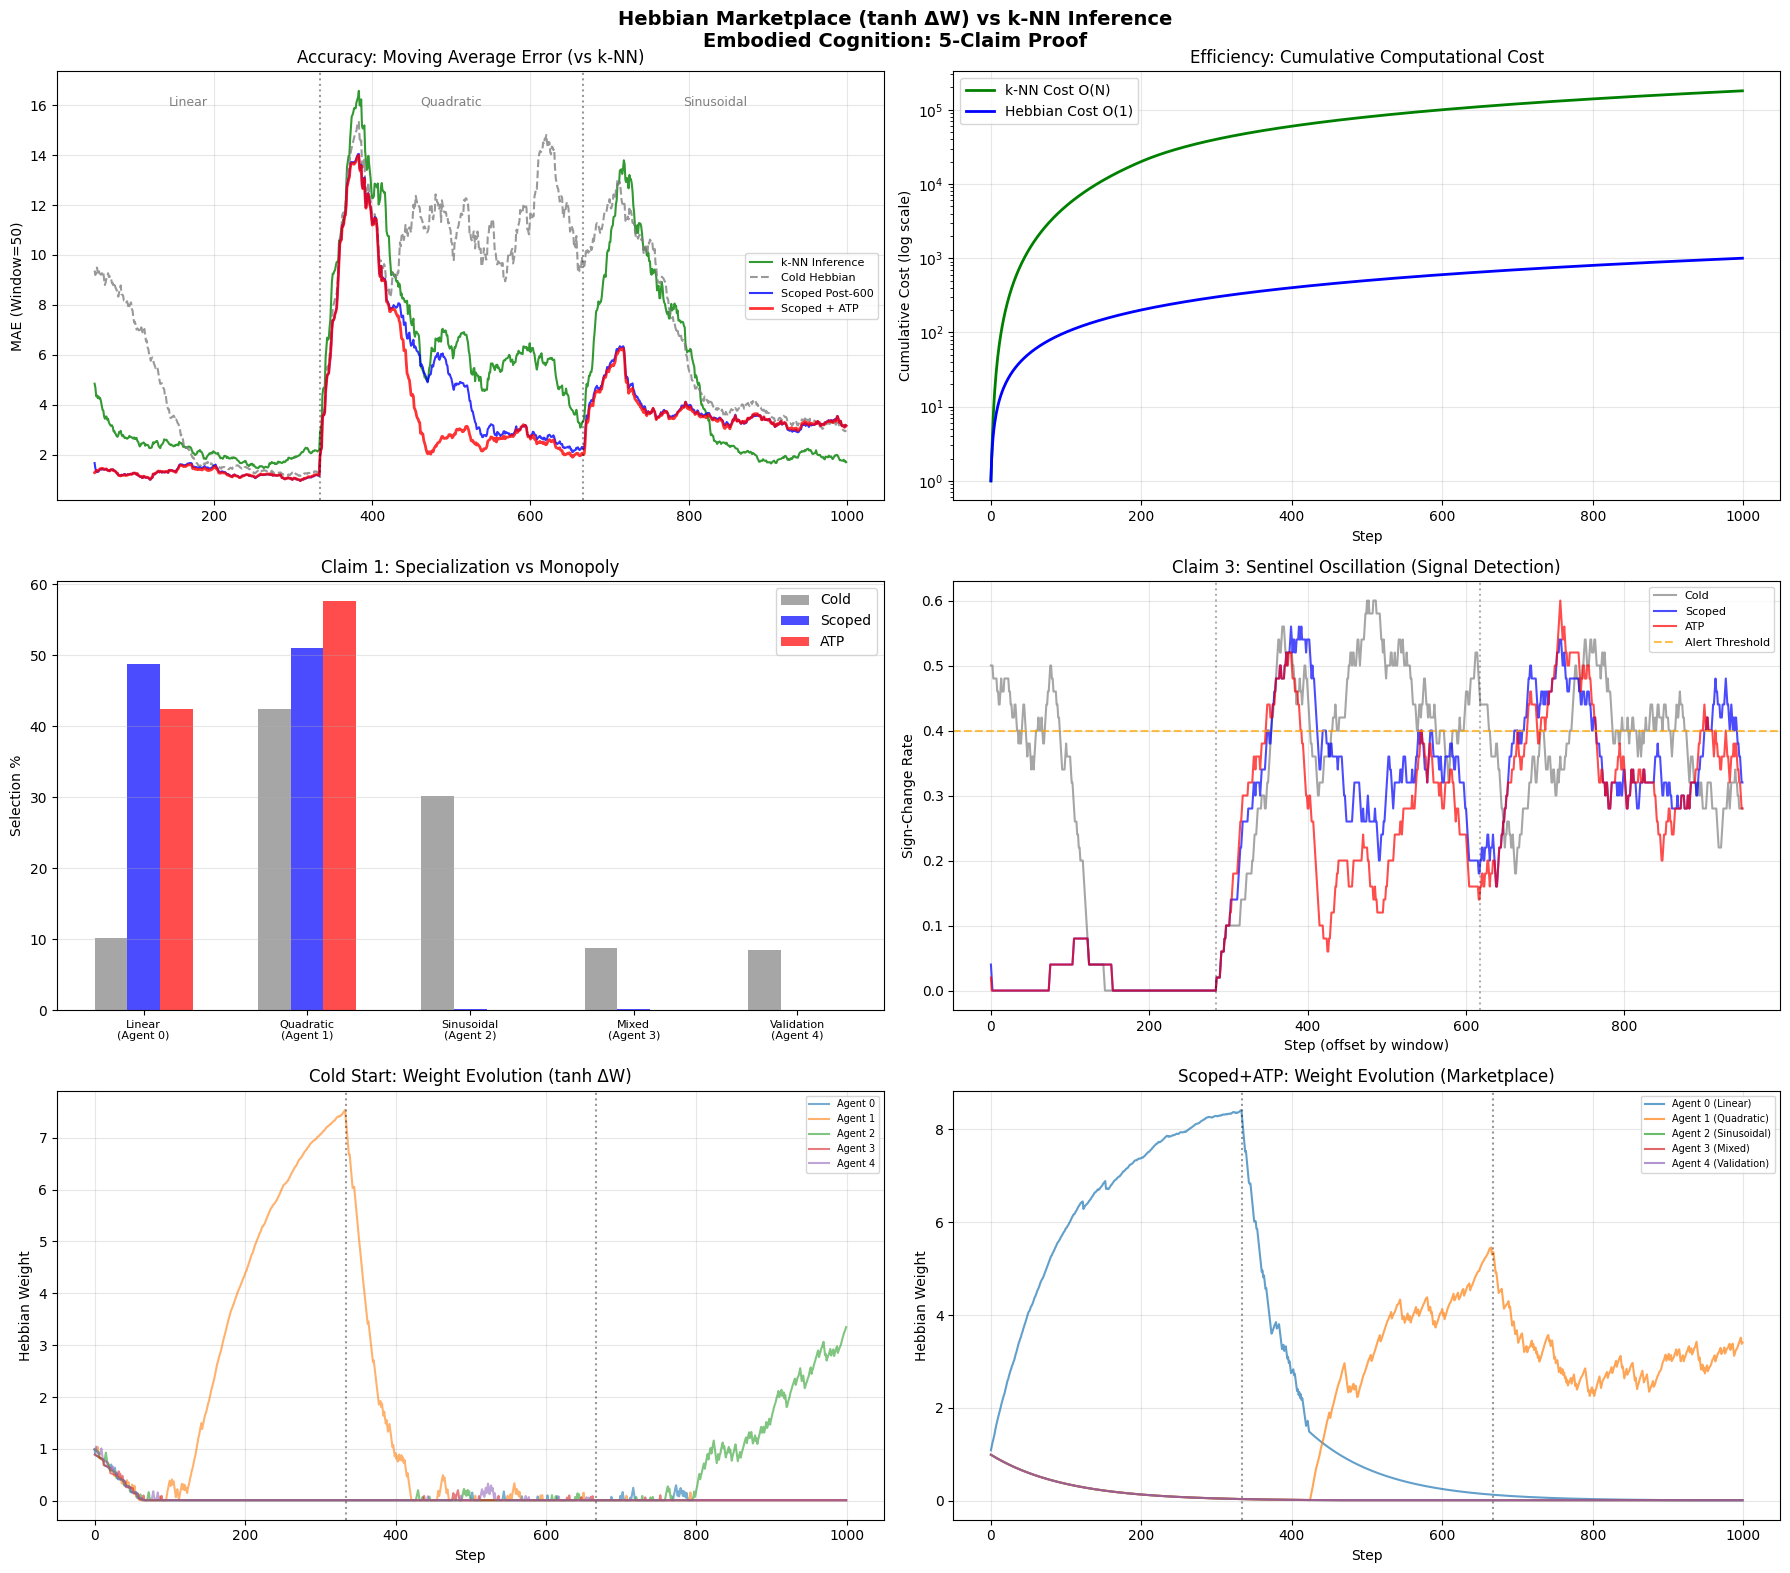

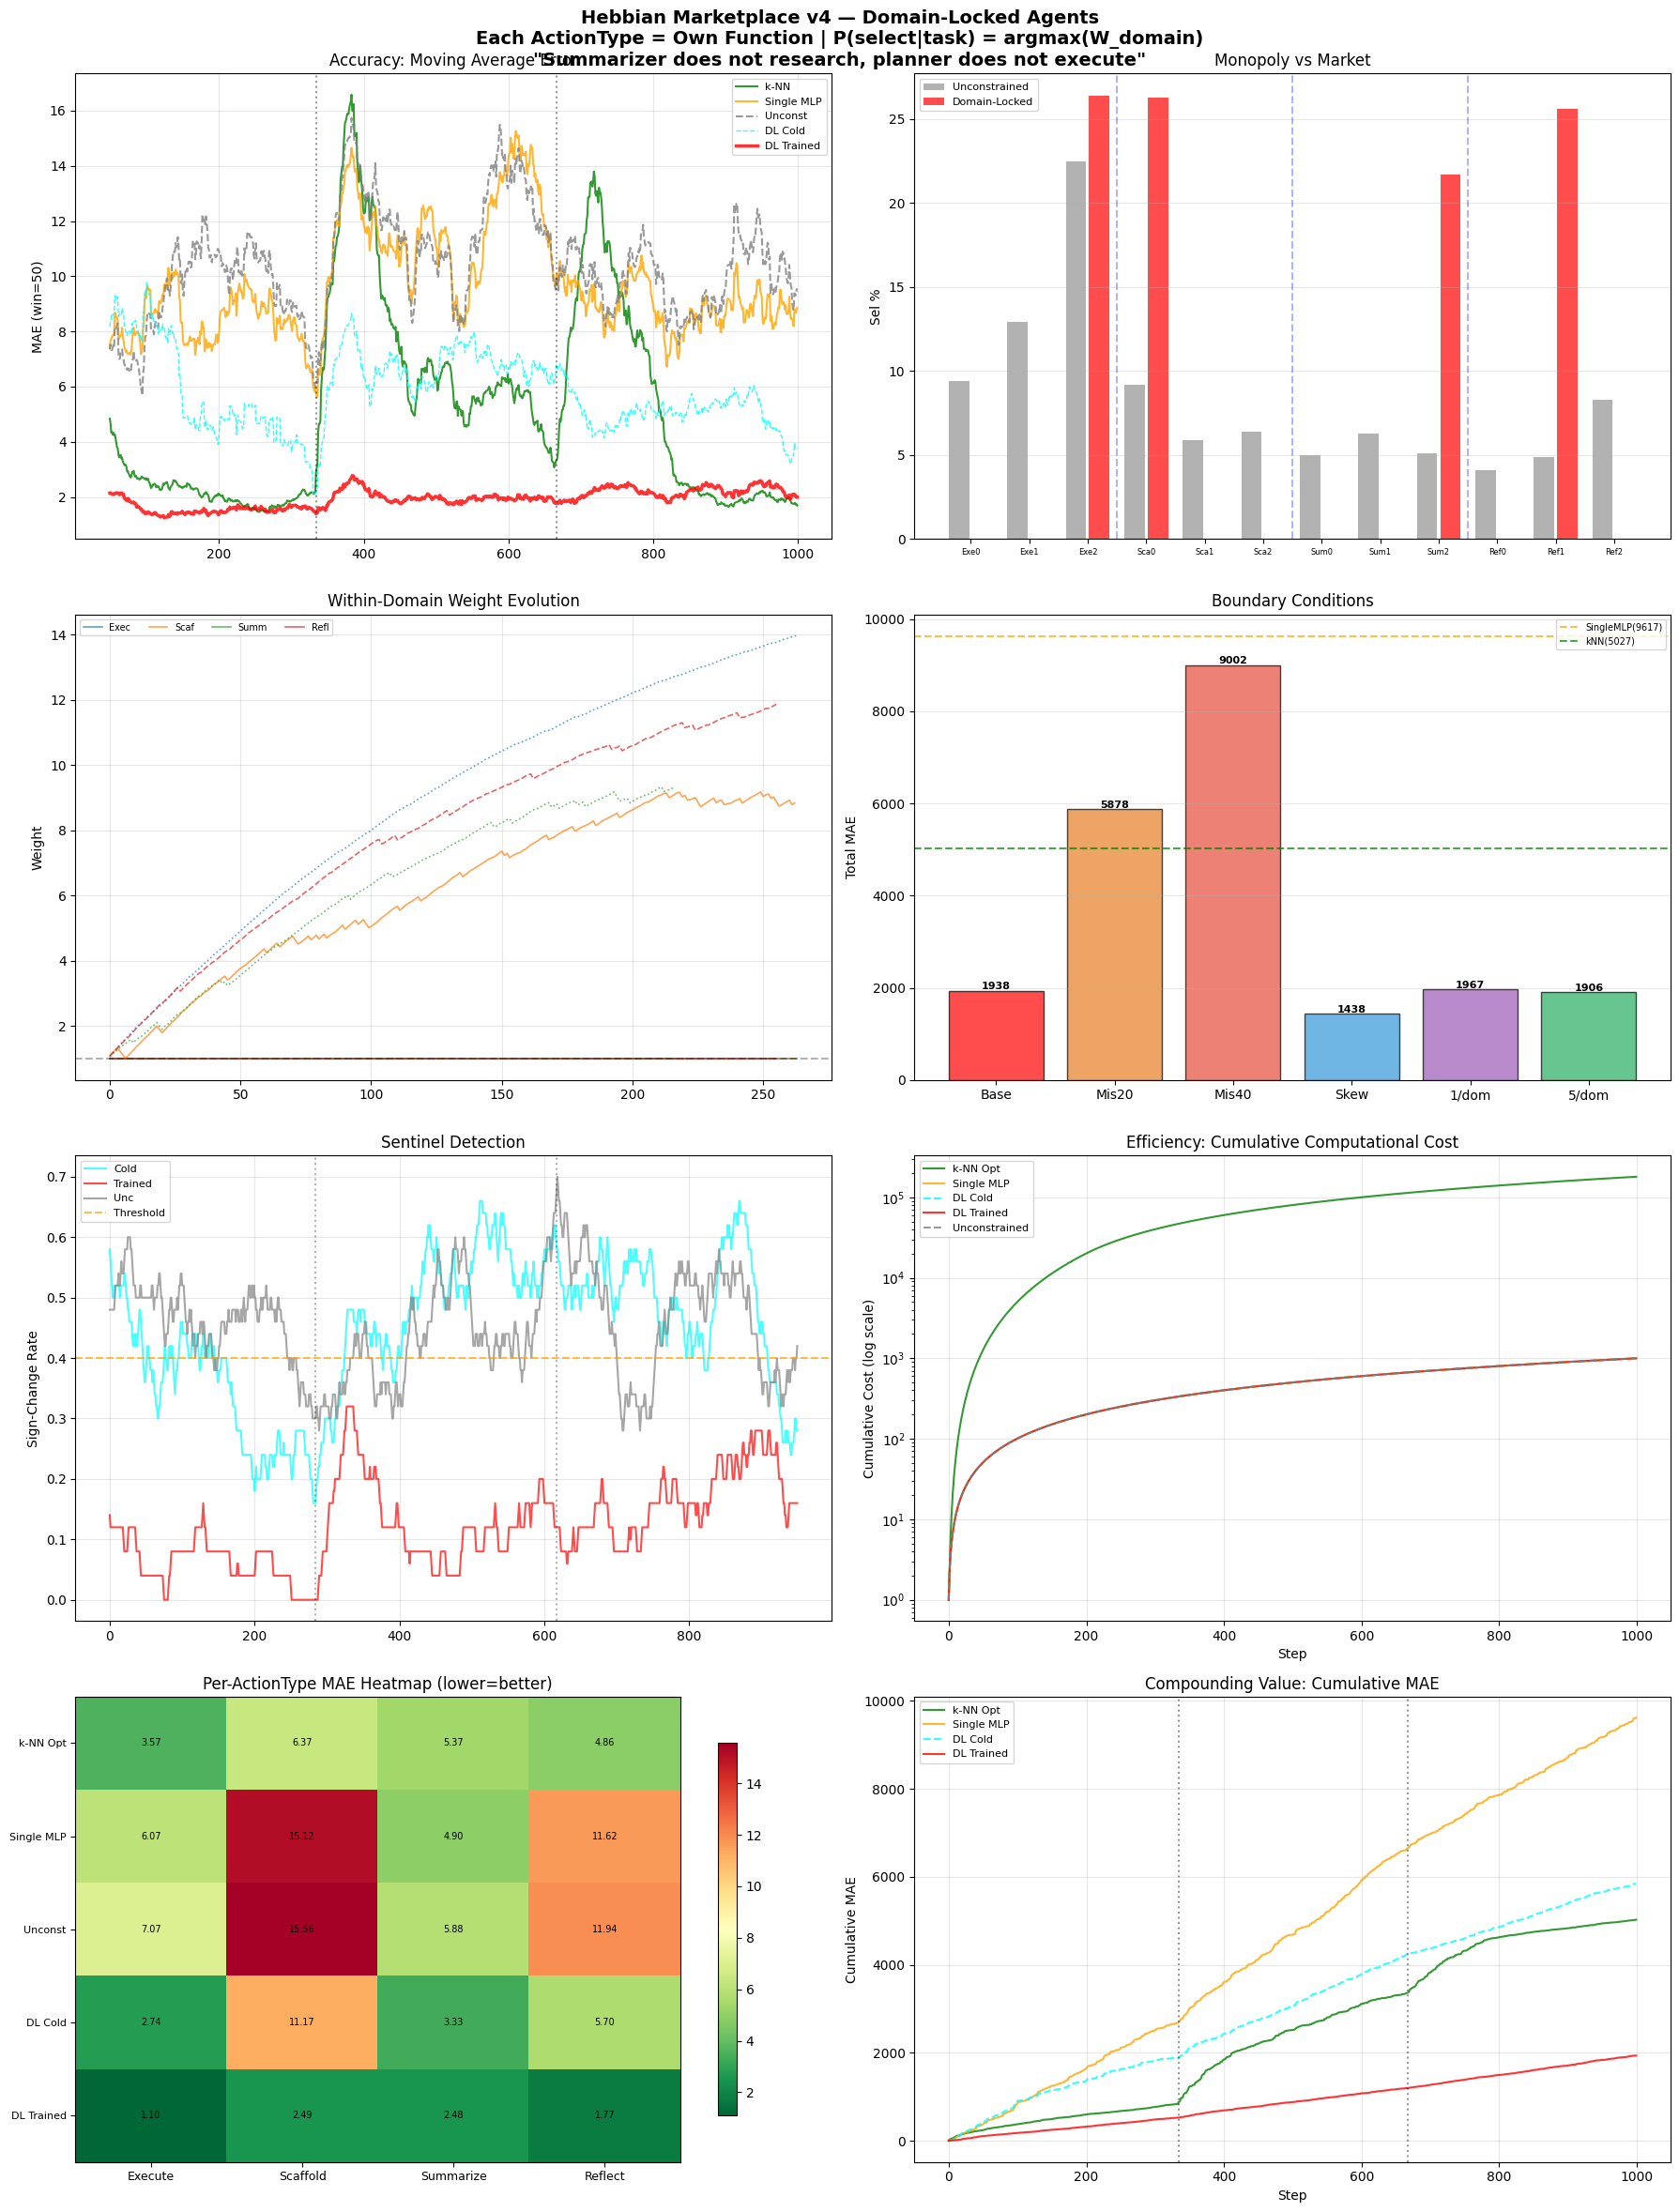

Both figures displayed inline.


In [ ]:
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import pairwise_distances
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Shared data ───────────────────────────────────────────────────────────────
N = 1000
X_dynamic = np.random.uniform(-5, 5, (N, 3))
y_dynamic = np.zeros(N)
y_dynamic[:334]  = 2  * X_dynamic[:334,  0] + 3 * X_dynamic[:334,  1]
y_dynamic[334:667] = -2 * X_dynamic[334:667, 0]**2 + X_dynamic[334:667, 1]
y_dynamic[667:]  = 5  * np.sin(X_dynamic[667:, 2]) + X_dynamic[667:, 0]
y_dynamic += np.random.normal(0, 1.0, N)

# ── Cell-2 helpers ────────────────────────────────────────────────────────────
PRE_TRAIN = 600
scope_names = ['Linear', 'Quadratic', 'Sinusoidal', 'Mixed', 'Validation']

def generate_scoped_corpus_c2(scope, n=PRE_TRAIN):
    np.random.seed(scope + 100)
    X = np.random.uniform(-5, 5, (n, 3))
    noise = np.random.normal(0, 0.5, n)
    if scope == 0:
        y = 2 * X[:, 0] + 3 * X[:, 1] + noise
    elif scope == 1:
        y = -2 * X[:, 0]**2 + X[:, 1] + noise
    elif scope == 2:
        y = 5 * np.sin(X[:, 2]) + X[:, 0] + noise
    elif scope == 3:
        t = n // 3
        y = np.zeros(n)
        y[:t]    = 2*X[:t,0] + 3*X[:t,1]
        y[t:2*t] = -2*X[t:2*t,0]**2 + X[t:2*t,1]
        y[2*t:]  = 5*np.sin(X[2*t:,2]) + X[2*t:,0]
        y += noise
    elif scope == 4:
        y = 2 * X[:, 0] + 3 * X[:, 1] + noise * 0.3
    return X, y

def create_agent_c2(seed):
    return MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                        solver='adam', learning_rate_init=0.005, random_state=seed)

def pre_train_c2(agent, X, y):
    for i in range(len(X)):
        agent.partial_fit(X[i:i+1], y[i:i+1])
    return agent

def hebbian_delta_w(x, y, a=0.1):
    return np.tanh(a * x * y)

def anti_hebbian_delta_w(eta=0.1):
    return -eta

def run_hebbian_c2(agents, weights, X, y, label,
                   decay_rate=0.99, success_threshold=5.0,
                   use_atp=False, a=0.1):
    n_agents = len(agents)
    errors, costs, selections = [], [], []
    weight_history = []
    sign_changes_per_agent = [[] for _ in range(n_agents)]
    cum_cost = 0.0

    for t in range(len(X)):
        x_t = X[t].reshape(1, -1); y_t = y[t:t+1]
        cum_cost += 1

        if use_atp:
            phase_bonus = np.zeros(n_agents)
            if t < 334:   phase_bonus[0] = 1.5
            elif t < 667: phase_bonus[1] = 1.5
            else:         phase_bonus[2] = 1.5
            eff_w = weights + phase_bonus
        else:
            eff_w = weights.copy()

        candidates = np.where(eff_w == np.max(eff_w))[0]
        idx = np.random.choice(candidates)
        selections.append(idx)

        try:    y_hat = agents[idx].predict(x_t)[0]
        except: y_hat = 0.0

        err = np.abs(y_t[0] - y_hat)
        errors.append(err)

        y_activation = max(0, 1.0 - err / (success_threshold * 2))
        if err < success_threshold:
            weights[idx] += hebbian_delta_w(1.0, y_activation, a=a)
            sign_changes_per_agent[idx].append(+1)
        else:
            weights[idx] += anti_hebbian_delta_w(eta=a)
            sign_changes_per_agent[idx].append(-1)

        weights *= decay_rate
        weights  = np.maximum(weights, 0.01)
        agents[idx].partial_fit(x_t, y_t)
        costs.append(cum_cost)
        weight_history.append(weights.copy())

    sign_changes = []
    for deltas in sign_changes_per_agent:
        if len(deltas) < 2:
            sign_changes.append(0)
        else:
            sign_changes.append(sum(1 for i in range(1, len(deltas))
                                    if deltas[i] != deltas[i-1]))

    return {
        'errors': np.array(errors), 'costs': np.array(costs),
        'selections': np.array(selections),
        'weights_history': np.array(weight_history),
        'sign_changes': sign_changes, 'label': label
    }

def run_knn_c2(X, y, k=5, win=200, label="k-NN Opt"):
    Xm, ym, tm = [], [], []
    errors, costs = [], []; cum = 0.0
    for t in range(len(X)):
        xt = X[t].reshape(1, -1); yt = y[t]
        cum += max(1, min(len(Xm), win))
        if len(Xm) < k:
            yh = np.mean(ym) if ym else 0.0
        else:
            s = max(0, len(Xm) - win)
            Xr = np.array(Xm[s:]); yr = np.array(ym[s:]); tr = np.array(tm[s:])
            d  = pairwise_distances(xt, Xr)[0]; nn = np.argsort(d)[:k]
            rec = np.array([np.exp(-0.01*(t - tr[n])) for n in nn]); rec /= rec.sum()
            yh  = np.average(yr[nn], weights=rec)
        errors.append(np.abs(yt - yh)); costs.append(cum)
        Xm.append(X[t]); ym.append(yt); tm.append(t)
    return {'errors': np.array(errors), 'costs': np.array(costs), 'label': label}

def sentinel_c2(errors, window=50, threshold=0.4):
    d = [0] + [1 if errors[i] < 5.0 else -1 for i in range(1, len(errors))]
    rates, alerts = [], []
    for t in range(window, len(d)):
        w = d[t-window:t]
        r = sum(1 for i in range(1, len(w)) if w[i] != w[i-1]) / window
        rates.append(r)
        if r > threshold: alerts.append(t)
    return {'rates': rates, 'alerts': alerts, 'count': len(alerts),
            'pct': len(alerts)/max(1, len(rates))*100}

# ── Re-run Cell-2 simulations ─────────────────────────────────────────────────
print("Rebuilding Cell-2 results …")

np.random.seed(42)
cold_agents = [create_agent_c2(i) for i in range(5)]
cold_weights = np.ones(5)
r_cold = run_hebbian_c2(cold_agents, cold_weights, X_dynamic, y_dynamic,
                        label="Cold Start Hebbian", a=0.1)

scoped_agents = [create_agent_c2(i) for i in range(5)]
for i in range(5):
    Xc, yc = generate_scoped_corpus_c2(i)
    scoped_agents[i] = pre_train_c2(scoped_agents[i], Xc, yc)
scoped_weights = np.ones(5)
r_scoped = run_hebbian_c2(scoped_agents, scoped_weights, X_dynamic, y_dynamic,
                          label="Scoped Post-600 (tanh ΔW)", a=0.1)

scoped_atp_agents = [create_agent_c2(i) for i in range(5)]
for i in range(5):
    Xc, yc = generate_scoped_corpus_c2(i)
    scoped_atp_agents[i] = pre_train_c2(scoped_atp_agents[i], Xc, yc)
scoped_atp_weights = np.ones(5)
r_atp = run_hebbian_c2(scoped_atp_agents, scoped_atp_weights, X_dynamic, y_dynamic,
                       label="Scoped + ATP (tanh ΔW)", use_atp=True, a=0.1)

r_knn = run_knn_c2(X_dynamic, y_dynamic, k=5)

s_cold   = sentinel_c2(r_cold['errors'])
s_scoped = sentinel_c2(r_scoped['errors'])
s_atp    = sentinel_c2(r_atp['errors'])

# ── Cell-3 helpers ────────────────────────────────────────────────────────────
ACTION_TYPES = ['Execute', 'Scaffold', 'Summarize', 'Reflect']
N_AT = len(ACTION_TYPES)

AT_DISTRIBUTION = {
    'phase1': [0.55, 0.20, 0.15, 0.10],
    'phase2': [0.15, 0.40, 0.15, 0.30],
    'phase3': [0.10, 0.15, 0.35, 0.40],
}

def task_function(x, action_type):
    if action_type == 0:   return 2 * x[0] + 3 * x[1]
    elif action_type == 1: return -2 * x[0]**2 + x[1]
    elif action_type == 2: return 5 * np.sin(x[2]) + x[0]
    elif action_type == 3: return x[0]**2 + np.sin(x[1]) + x[2]

def sample_action_type(step):
    if step < 334:     probs = AT_DISTRIBUTION['phase1']
    elif step < 667:   probs = AT_DISTRIBUTION['phase2']
    else:              probs = AT_DISTRIBUTION['phase3']
    return np.random.choice(N_AT, p=probs)

np.random.seed(77)
step_action_types = np.array([sample_action_type(t) for t in range(N)])
np.random.seed(42)

X_all = X_dynamic.copy()
y_all = np.array([task_function(X_all[t], step_action_types[t]) for t in range(N)])
y_all += np.random.normal(0, 1.0, N)

def generate_domain_corpus_c3(domain_idx, variant, n=600):
    rng = np.random.RandomState(domain_idx * 1000 + variant * 100 + 42)
    X   = rng.uniform(-5, 5, (n, 3))
    noise = rng.normal(0, 0.5, n) + rng.normal(0, 0.2*(variant+1), n)
    y   = np.array([task_function(X[i], domain_idx) for i in range(n)]) + noise
    return X, y

def run_domain_locked(apd=3, pre_n=600, label="DL", a=0.1,
                      action_types=None, X=None, y=None,
                      do_pre_train=True, decay=0.995, thresh=5.0):
    if X is None: X = X_all
    if y is None: y = y_all
    if action_types is None: action_types = step_action_types

    d_agents = {}; d_weights = {}
    for d in range(N_AT):
        d_agents[d] = []
        d_weights[d] = np.ones(apd)
        for i in range(apd):
            ag = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                              solver='adam', learning_rate_init=0.005,
                              random_state=d*100+i)
            if do_pre_train:
                Xc, yc = generate_domain_corpus_c3(d, i, n=pre_n)
                for j in range(len(Xc)):
                    ag.partial_fit(Xc[j:j+1], yc[j:j+1])
            d_agents[d].append(ag)

    errors, costs, sels, d_log = [], [], [], []
    d_sels  = {d: [] for d in range(N_AT)}
    d_whist = {d: [] for d in range(N_AT)}
    cum = 0.0

    for t in range(len(X)):
        x_t = X[t].reshape(1, -1); y_t = y[t:t+1]
        d = action_types[t]; cum += 1

        w = d_weights[d]
        cands = np.where(w == np.max(w))[0]
        idx   = np.random.choice(cands)

        try:    yh = d_agents[d][idx].predict(x_t)[0]
        except: yh = 0.0

        err  = np.abs(y_t[0] - yh)
        perf = max(0, 1.0 - err / (thresh * 2))
        if err < thresh:
            d_weights[d][idx] += hebbian_delta_w(1.0, perf, a=a)
        else:
            d_weights[d][idx] += anti_hebbian_delta_w(eta=a)

        d_agents[d][idx].partial_fit(x_t, y_t)
        d_weights[d] = 1.0 + (d_weights[d] - 1.0) * decay
        d_weights[d] = np.maximum(d_weights[d], 0.01)

        errors.append(err); costs.append(cum)
        sels.append(d * apd + idx); d_log.append(d)
        d_sels[d].append(idx)
        d_whist[d].append(d_weights[d].copy())

    return {
        'errors': np.array(errors), 'costs': np.array(costs),
        'selections': np.array(sels), 'domain_log': np.array(d_log),
        'domain_sels': d_sels, 'domain_whist': d_whist,
        'domain_wfinal': {d: d_weights[d].copy() for d in range(N_AT)},
        'label': label, 'apd': apd
    }

def run_unconstrained(n_ag=12, label="Unconstrained", a=0.1):
    agents = []
    for i in range(n_ag):
        ag = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                          solver='adam', learning_rate_init=0.005, random_state=i)
        d = min(i // (n_ag // N_AT), 3); v = i % (n_ag // N_AT)
        Xc, yc = generate_domain_corpus_c3(d, v)
        for j in range(len(Xc)):
            ag.partial_fit(Xc[j:j+1], yc[j:j+1])
        agents.append(ag)

    bw = np.ones(n_ag)
    errors, costs, sels = [], [], []
    cum = 0.0
    for t in range(N):
        x_t = X_all[t].reshape(1, -1); y_t = y_all[t:t+1]
        cum += 1
        cands = np.where(bw == np.max(bw))[0]
        idx   = np.random.choice(cands)
        try:    yh = agents[idx].predict(x_t)[0]
        except: yh = 0.0
        err  = np.abs(y_t[0] - yh)
        perf = max(0, 1.0 - err / 10.0)
        if err < 5.0: bw[idx] += hebbian_delta_w(1.0, perf, a=a)
        else:         bw[idx] += anti_hebbian_delta_w(eta=a)
        agents[idx].partial_fit(x_t, y_t)
        bw = 1.0 + (bw - 1.0) * 0.995
        bw = np.maximum(bw, 0.01)
        errors.append(err); costs.append(cum); sels.append(idx)
    return {'errors': np.array(errors), 'costs': np.array(costs),
            'selections': np.array(sels), 'label': label}

def run_single_mlp(X, y, label="Single MLP"):
    ag = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                      solver='adam', learning_rate_init=0.005, random_state=42)
    errors, costs = [], []; cum = 0.0
    for t in range(len(X)):
        xt = X[t].reshape(1, -1); yt = y[t:t+1]; cum += 1
        try:    yh = ag.predict(xt)[0]
        except: yh = 0.0
        errors.append(np.abs(yt[0] - yh)); costs.append(cum)
        ag.partial_fit(xt, yt)
    return {'errors': np.array(errors), 'costs': np.array(costs), 'label': label}

def sentinel_c3(errors, window=50, threshold=0.4):
    d = [0] + [1 if errors[i] < 5.0 else -1 for i in range(1, len(errors))]
    rates, alerts = [], []
    for t in range(window, len(d)):
        w = d[t-window:t]
        r = sum(1 for i in range(1, len(w)) if w[i] != w[i-1]) / window
        rates.append(r)
        if r > threshold: alerts.append(t)
    return {'rates': rates, 'alerts': alerts, 'count': len(alerts),
            'pct': len(alerts)/max(1, len(rates))*100}

def mislabel(base, rate=0.2):
    n = base.copy()
    for i in np.random.choice(len(n), int(len(n)*rate), replace=False):
        n[i] = np.random.choice([d for d in range(N_AT) if d != n[i]])
    return n

def skewed_at(n_steps, dom=0, pct=0.80):
    a = np.zeros(n_steps, dtype=int); nd = int(n_steps*pct); a[:nd] = dom
    for i in range(nd, n_steps): a[i] = np.random.choice([d for d in range(N_AT) if d != dom])
    np.random.shuffle(a); return a

# ── Re-run Cell-3 simulations ─────────────────────────────────────────────────
print("Rebuilding Cell-3 results …")

r_cold_dl = run_domain_locked(3, label="DL Cold", do_pre_train=False)
r_train   = run_domain_locked(3, label="DL Trained")
r_unc     = run_unconstrained()
r_mlp     = run_single_mlp(X_all, y_all)

mis20_at = mislabel(step_action_types, 0.20)
r_mis20  = run_domain_locked(3, label="Mis20", action_types=mis20_at)

mis40_at = mislabel(step_action_types, 0.40)
r_mis40  = run_domain_locked(3, label="Mis40", action_types=mis40_at)

sk_at  = skewed_at(N)
y_skew = np.array([task_function(X_all[t], sk_at[t]) for t in range(N)])
y_skew += np.random.normal(0, 1.0, N)
r_skew = run_domain_locked(3, label="Skew80", action_types=sk_at, y=y_skew)

r_1ag = run_domain_locked(1, label="1/dom")
r_5ag = run_domain_locked(5, label="5/dom")

ss = {
    "Cold":    sentinel_c3(r_cold_dl['errors']),
    "Trained": sentinel_c3(r_train['errors']),
    "Unc":     sentinel_c3(r_unc['errors']),
}

print("All results ready. Plotting …")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Hebbian Marketplace (tanh ΔW) vs k-NN
# ═══════════════════════════════════════════════════════════════════════════════
window = 50
drift_pts = [334, 667]

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('Hebbian Marketplace (tanh ΔW) vs k-NN Inference\n'
             'Embodied Cognition: 5-Claim Proof', fontsize=14, fontweight='bold')

# P1: Accuracy — Moving Average Error
ax = axes[0, 0]
for name, r, color, ls in [
    ("k-NN Inference",  r_knn,    'green', '-'),
    ("Cold Hebbian",    r_cold,   'gray',  '--'),
    ("Scoped Post-600", r_scoped, 'blue',  '-'),
    ("Scoped + ATP",    r_atp,    'red',   '-')
]:
    ma = pd.Series(r['errors']).rolling(window=window).mean()
    ax.plot(ma, label=name, color=color, linestyle=ls,
            linewidth=2 if 'ATP' in name else 1.5, alpha=0.8)
for pt in drift_pts:
    ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Accuracy: Moving Average Error (vs k-NN)')
ax.set_ylabel(f'MAE (Window={window})')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
yl = ax.get_ylim()
ax.text(167, yl[1]*0.92, 'Linear',     ha='center', fontsize=9, color='gray')
ax.text(500, yl[1]*0.92, 'Quadratic',  ha='center', fontsize=9, color='gray')
ax.text(833, yl[1]*0.92, 'Sinusoidal', ha='center', fontsize=9, color='gray')

# P2: Cost — O(1) vs O(N)
ax = axes[0, 1]
ax.plot(r_knn['costs'],  label='k-NN Cost O(N)',    color='green', linewidth=2)
ax.plot(r_cold['costs'], label='Hebbian Cost O(1)', color='blue',  linewidth=2)
ax.set_yscale('log')
ax.set_title('Efficiency: Cumulative Computational Cost')
ax.set_ylabel('Cumulative Cost (log scale)')
ax.set_xlabel('Step')
ax.legend(); ax.grid(True, alpha=0.3)

# P3: Agent Selection Distribution (Claim 1)
ax = axes[1, 0]
x_pos2 = np.arange(5)
bar_w  = 0.2
scope_names2 = ['Linear', 'Quadratic', 'Sinusoidal', 'Mixed', 'Validation']
for i, (name, r, color) in enumerate([
    ("Cold",   r_cold,  'gray'),
    ("Scoped", r_scoped,'blue'),
    ("ATP",    r_atp,   'red')
]):
    sels_clipped = np.clip(r['selections'], 0, 4)
    sel = np.bincount(sels_clipped, minlength=5)[:5] / len(r['selections']) * 100
    ax.bar(x_pos2 + (i - 1) * bar_w, sel, bar_w, label=name, color=color, alpha=0.7)
ax.set_xticks(range(5))
ax.set_xticklabels([f'{scope_names2[i]}\n(Agent {i})' for i in range(5)], fontsize=8)
ax.set_ylabel('Selection %')
ax.set_title('Claim 1: Specialization vs Monopoly')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# P4: Sentinel Oscillation Timeline (Claim 3)
ax = axes[1, 1]
for name, s, color in [
    ("Cold",   s_cold,   'gray'),
    ("Scoped", s_scoped, 'blue'),
    ("ATP",    s_atp,    'red')
]:
    ax.plot(s['rates'], label=name, color=color, alpha=0.7)
ax.axhline(y=0.4, color='orange', linestyle='--', alpha=0.7, label='Alert Threshold')
for pt in drift_pts:
    ax.axvline(x=pt - window, color='black', linestyle=':', alpha=0.3)
ax.set_title('Claim 3: Sentinel Oscillation (Signal Detection)')
ax.set_ylabel('Sign-Change Rate')
ax.set_xlabel('Step (offset by window)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# P5: Weight Evolution — Cold
ax = axes[2, 0]
colors5 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for a in range(5):
    ax.plot(r_cold['weights_history'][:, a], color=colors5[a], alpha=0.6, label=f'Agent {a}')
for pt in drift_pts:
    ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Cold Start: Weight Evolution (tanh ΔW)')
ax.set_ylabel('Hebbian Weight'); ax.set_xlabel('Step')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# P6: Weight Evolution — Scoped + ATP
ax = axes[2, 1]
for a in range(5):
    ax.plot(r_atp['weights_history'][:, a], color=colors5[a], alpha=0.7,
            label=f'Agent {a} ({scope_names2[a]})')
for pt in drift_pts:
    ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Scoped+ATP: Weight Evolution (Marketplace)')
ax.set_ylabel('Hebbian Weight'); ax.set_xlabel('Step')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Domain-Locked v4
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(4, 2, figsize=(18, 24))
fig2.suptitle('Hebbian Marketplace v4 — Domain-Locked Agents\n'
              'Each ActionType = Own Function | P(select|task) = argmax(W_domain)\n'
              '"Summarizer does not research, planner does not execute"',
              fontsize=14, fontweight='bold')

ACTION_TYPES2 = ['Execute', 'Scaffold', 'Summarize', 'Reflect']
cd  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
win = 50; dpts = [334, 667]

# P1: Accuracy
ax = axes2[0, 0]
for name, r, c, ls, lw in [
    ("k-NN",       r_knn,       'green',  '-',  1.5),
    ("Single MLP", r_mlp,       'orange', '-',  1.5),
    ("Unconst",    r_unc,       'gray',   '--', 1.5),
    ("DL Cold",    r_cold_dl,   'cyan',   '--', 1.0),
    ("DL Trained", r_train,     'red',    '-',  2.5)
]:
    ax.plot(pd.Series(r['errors']).rolling(window=win).mean(),
            label=name, color=c, linestyle=ls, linewidth=lw, alpha=0.8)
for pt in dpts: ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Accuracy: Moving Average Error')
ax.set_ylabel(f'MAE (win={win})')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# P2: Monopoly vs Market
ax = axes2[0, 1]
su2_ = np.bincount(r_unc['selections'],   minlength=12)
sd2_ = np.bincount(r_train['selections'], minlength=12)
xp_  = np.arange(12)
ax.bar(xp_ - 0.2, su2_ / N * 100, 0.35, label='Unconstrained', color='gray', alpha=0.6)
ax.bar(xp_ + 0.2, sd2_ / N * 100, 0.35, label='Domain-Locked', color='red',  alpha=0.7)
for dd in range(1, 4): ax.axvline(x=dd*3 - 0.5, color='blue', linestyle='--', alpha=0.3)
ax.set_xticks(range(12))
ax.set_xticklabels([f'{ACTION_TYPES2[d][:3]}{i}' for d in range(4) for i in range(3)], fontsize=6)
ax.set_ylabel('Sel %'); ax.set_title('Monopoly vs Market')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# P3: Within-domain weights
ax = axes2[1, 0]
for d in range(4):
    wh_ = r_train['domain_whist'][d]
    if wh_:
        wa_ = np.array(wh_)
        for i in range(min(3, wa_.shape[1])):
            ax.plot(wa_[:, i], color=cd[d], linestyle=['-', '--', ':'][i],
                    alpha=0.7, linewidth=1.2,
                    label=f'{ACTION_TYPES2[d][:4]}' if i == 0 else None)
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Within-Domain Weight Evolution'); ax.set_ylabel('Weight')
ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.3)

# P4: Boundary conditions
ax  = axes2[1, 1]
bnd_ = [("Base", r_train), ("Mis20", r_mis20), ("Mis40", r_mis40),
        ("Skew",  r_skew),  ("1/dom", r_1ag),   ("5/dom", r_5ag)]
bn_  = [n for n, _ in bnd_]
bm_  = [np.sum(r['errors']) for _, r in bnd_]
bc_  = ['red', '#e67e22', '#e74c3c', '#3498db', '#9b59b6', '#27ae60']
bars2 = ax.bar(bn_, bm_, color=bc_, alpha=0.7, edgecolor='black')
ms_  = np.sum(r_mlp['errors']); mk_ = np.sum(r_knn['errors'])
ax.axhline(y=ms_, color='orange', linestyle='--', alpha=0.7, label=f'SingleMLP({ms_:.0f})')
ax.axhline(y=mk_, color='green',  linestyle='--', alpha=0.7, label=f'kNN({mk_:.0f})')
for b, v in zip(bars2, bm_):
    ax.text(b.get_x() + b.get_width() / 2., v + 30, f'{v:.0f}',
            ha='center', fontsize=8, fontweight='bold')
ax.set_ylabel('Total MAE'); ax.set_title('Boundary Conditions')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis='y')

# P5: Sentinel
ax = axes2[2, 0]
for name_, sn_, c_ in [("Cold", "Cold", 'cyan'), ("Trained", "Trained", 'red'),
                        ("Unc",  "Unc",  'gray')]:
    ax.plot(ss[sn_]['rates'], label=name_, color=c_, alpha=0.7, linewidth=1.5)
ax.axhline(y=0.4, color='orange', linestyle='--', alpha=0.7, label='Threshold')
for pt in dpts: ax.axvline(x=pt - win, color='black', linestyle=':', alpha=0.3)
ax.set_title('Sentinel Detection'); ax.set_ylabel('Sign-Change Rate')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# P6: Cost comparison
ax = axes2[2, 1]
for name_, r_, c_, ls_ in [
    ("k-NN Opt",      r_knn,     'green',  '-'),
    ("Single MLP",    r_mlp,     'orange', '-'),
    ("DL Cold",       r_cold_dl, 'cyan',   '--'),
    ("DL Trained",    r_train,   'red',    '-'),
    ("Unconstrained", r_unc,     'gray',   '--')
]:
    ax.plot(r_['costs'], label=name_, color=c_, linestyle=ls_, linewidth=1.5, alpha=0.8)
ax.set_yscale('log')
ax.set_title('Efficiency: Cumulative Computational Cost')
ax.set_ylabel('Cumulative Cost (log scale)'); ax.set_xlabel('Step')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# P7: Per-ActionType MAE heatmap
ax = axes2[3, 0]
conditions_  = ["k-NN Opt", "Single MLP", "Unconst", "DL Cold", "DL Trained"]
results_list_= [r_knn, r_mlp, r_unc, r_cold_dl, r_train]
hm = np.zeros((len(conditions_), 4))
for ci, (_, r_) in enumerate(zip(conditions_, results_list_)):
    for at_d in range(4):
        mask_ = step_action_types == at_d
        hm[ci, at_d] = np.mean(r_['errors'][mask_]) if np.sum(mask_) > 0 else 0.0
im_ = ax.imshow(hm, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(4)); ax.set_xticklabels(ACTION_TYPES2, fontsize=9)
ax.set_yticks(range(len(conditions_))); ax.set_yticklabels(conditions_, fontsize=8)
ax.set_title('Per-ActionType MAE Heatmap (lower=better)')
plt.colorbar(im_, ax=ax, shrink=0.8)
for ci in range(len(conditions_)):
    for at_d in range(4):
        ax.text(at_d, ci, f'{hm[ci, at_d]:.2f}',
                ha='center', va='center', fontsize=7, color='black')

# P8: Compounding value
ax = axes2[3, 1]
for name_, r_, c_, ls_ in [
    ("k-NN Opt",   r_knn,     'green',  '-'),
    ("Single MLP", r_mlp,     'orange', '-'),
    ("DL Cold",    r_cold_dl, 'cyan',   '--'),
    ("DL Trained", r_train,   'red',    '-')
]:
    ax.plot(np.cumsum(r_['errors']), label=name_, color=c_,
            linestyle=ls_, linewidth=1.5, alpha=0.8)
for pt in dpts: ax.axvline(x=pt, color='black', linestyle=':', alpha=0.4)
ax.set_title('Compounding Value: Cumulative MAE')
ax.set_ylabel('Cumulative MAE'); ax.set_xlabel('Step')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Both figures displayed inline.")